## Load Database

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, StandardScaler, PolynomialFeatures 
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, f1_score, root_mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier, DummyRegressor

from scipy.stats import skew
from scipy import stats
from collections import Counter
from sklearn.datasets import make_classification, make_regression
tscv = TimeSeriesSplit(n_splits=5)

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve
from scipy import stats
from scipy.stats import ttest_rel

In [2]:
df = pd.read_csv(r"C:\Users\thilt\OneDrive\Desktop\Hackathon\accidents.csv", low_memory=False)
df.head(3)

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,...,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
0,IC,Illinois Central Railroad Company,2011,719563,https://safetydata.fra.dot.gov/Officeofsafety/...,11,8,NaN,NaN,NaN,...,Canadian National - North America,Canadian National - North America,Class III,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,POINT (-87.646405 41.58461)
1,CP,Canadian Pacific Railway Company,2013,239670,https://safetydata.fra.dot.gov/Officeofsafety/...,13,12,NaN,NaN,NaN,...,CANADIAN PACIFIC KANSAS CITY,Not Assigned,Class III,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,POINT (-87.903828 41.948197)
2,IANR,Iowa Northern Railway Company,2018,PLD0519182,https://safetydata.fra.dot.gov/Officeofsafety/...,18,5,NaN,NaN,NaN,...,Iowa Northern Railway Company,Not Assigned,Class III,Yes,Unassigned,Unassigned,Yes,Yes,Unassigned,POINT (-91.763351 42.033495)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224704 entries, 0 to 224703
Columns: 155 entries, Reporting Railroad Code to Location
dtypes: float64(25), int64(49), object(81)
memory usage: 265.7+ MB


In [4]:
df.shape

(224704, 155)

In [5]:
df.describe()

,Year,Accident Year,Accident Month,Other Accident Year,Other Accident Month,Maintenance Accident Year,Maintenance Accident Month,Day,Accident Type Code,Hazmat Cars,...,Others Injured,Reporting Railroad Fatalities for 55a,Reporting Railroad Injuries for 55a,Total Persons Killed,Total Persons Injured,Total Killed Form 54,Total Injured Form 54,Latitude,Longitude,Joint CD
count,224704.000000,224704.000000,224704.000000,19502.000000,19502.000000,224702.000000,224702.000000,224704.000000,224704.000000,224704.000000,...,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,70136.000000,70152.000000,224704.000000
mean,1993.240200,57.764641,6.432872,57.673110,6.440929,57.764942,6.432876,15.684420,3.406508,1.354395,...,0.032385,0.015078,0.158974,0.019417,0.210566,0.010378,0.126869,20.263719,-49.744623,1.311508
std,15.200545,35.285135,3.453805,35.158877,3.461773,35.285149,3.453787,8.753871,3.902550,6.391976,...,2.545053,0.206705,3.435767,0.259472,3.844788,0.183276,3.406570,19.174951,47.166292,0.678269
min,1975.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-181.078754,1.000000
25%,1979.000000,17.000000,3.000000,17.000000,3.000000,17.000000,3.000000,8.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-92.063158,1.000000
50%,1990.000000,77.000000,6.000000,77.000000,6.000000,77.000000,6.000000,16.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.915840,-75.082625,1.000000
75%,2005.000000,84.000000,9.000000,83.000000,9.000000,84.000000,9.000000,23.000000,4.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.128507,0.000000,1.000000
max,2026.000000,99.000000,12.000000,99.000000,12.000000,99.000000,12.000000,31.000000,13.000000,182.000000,...,999.000000,47.000000,558.000000,47.000000,558.000000,47.000000,1000.000000,64.845300,0.000000,3.000000


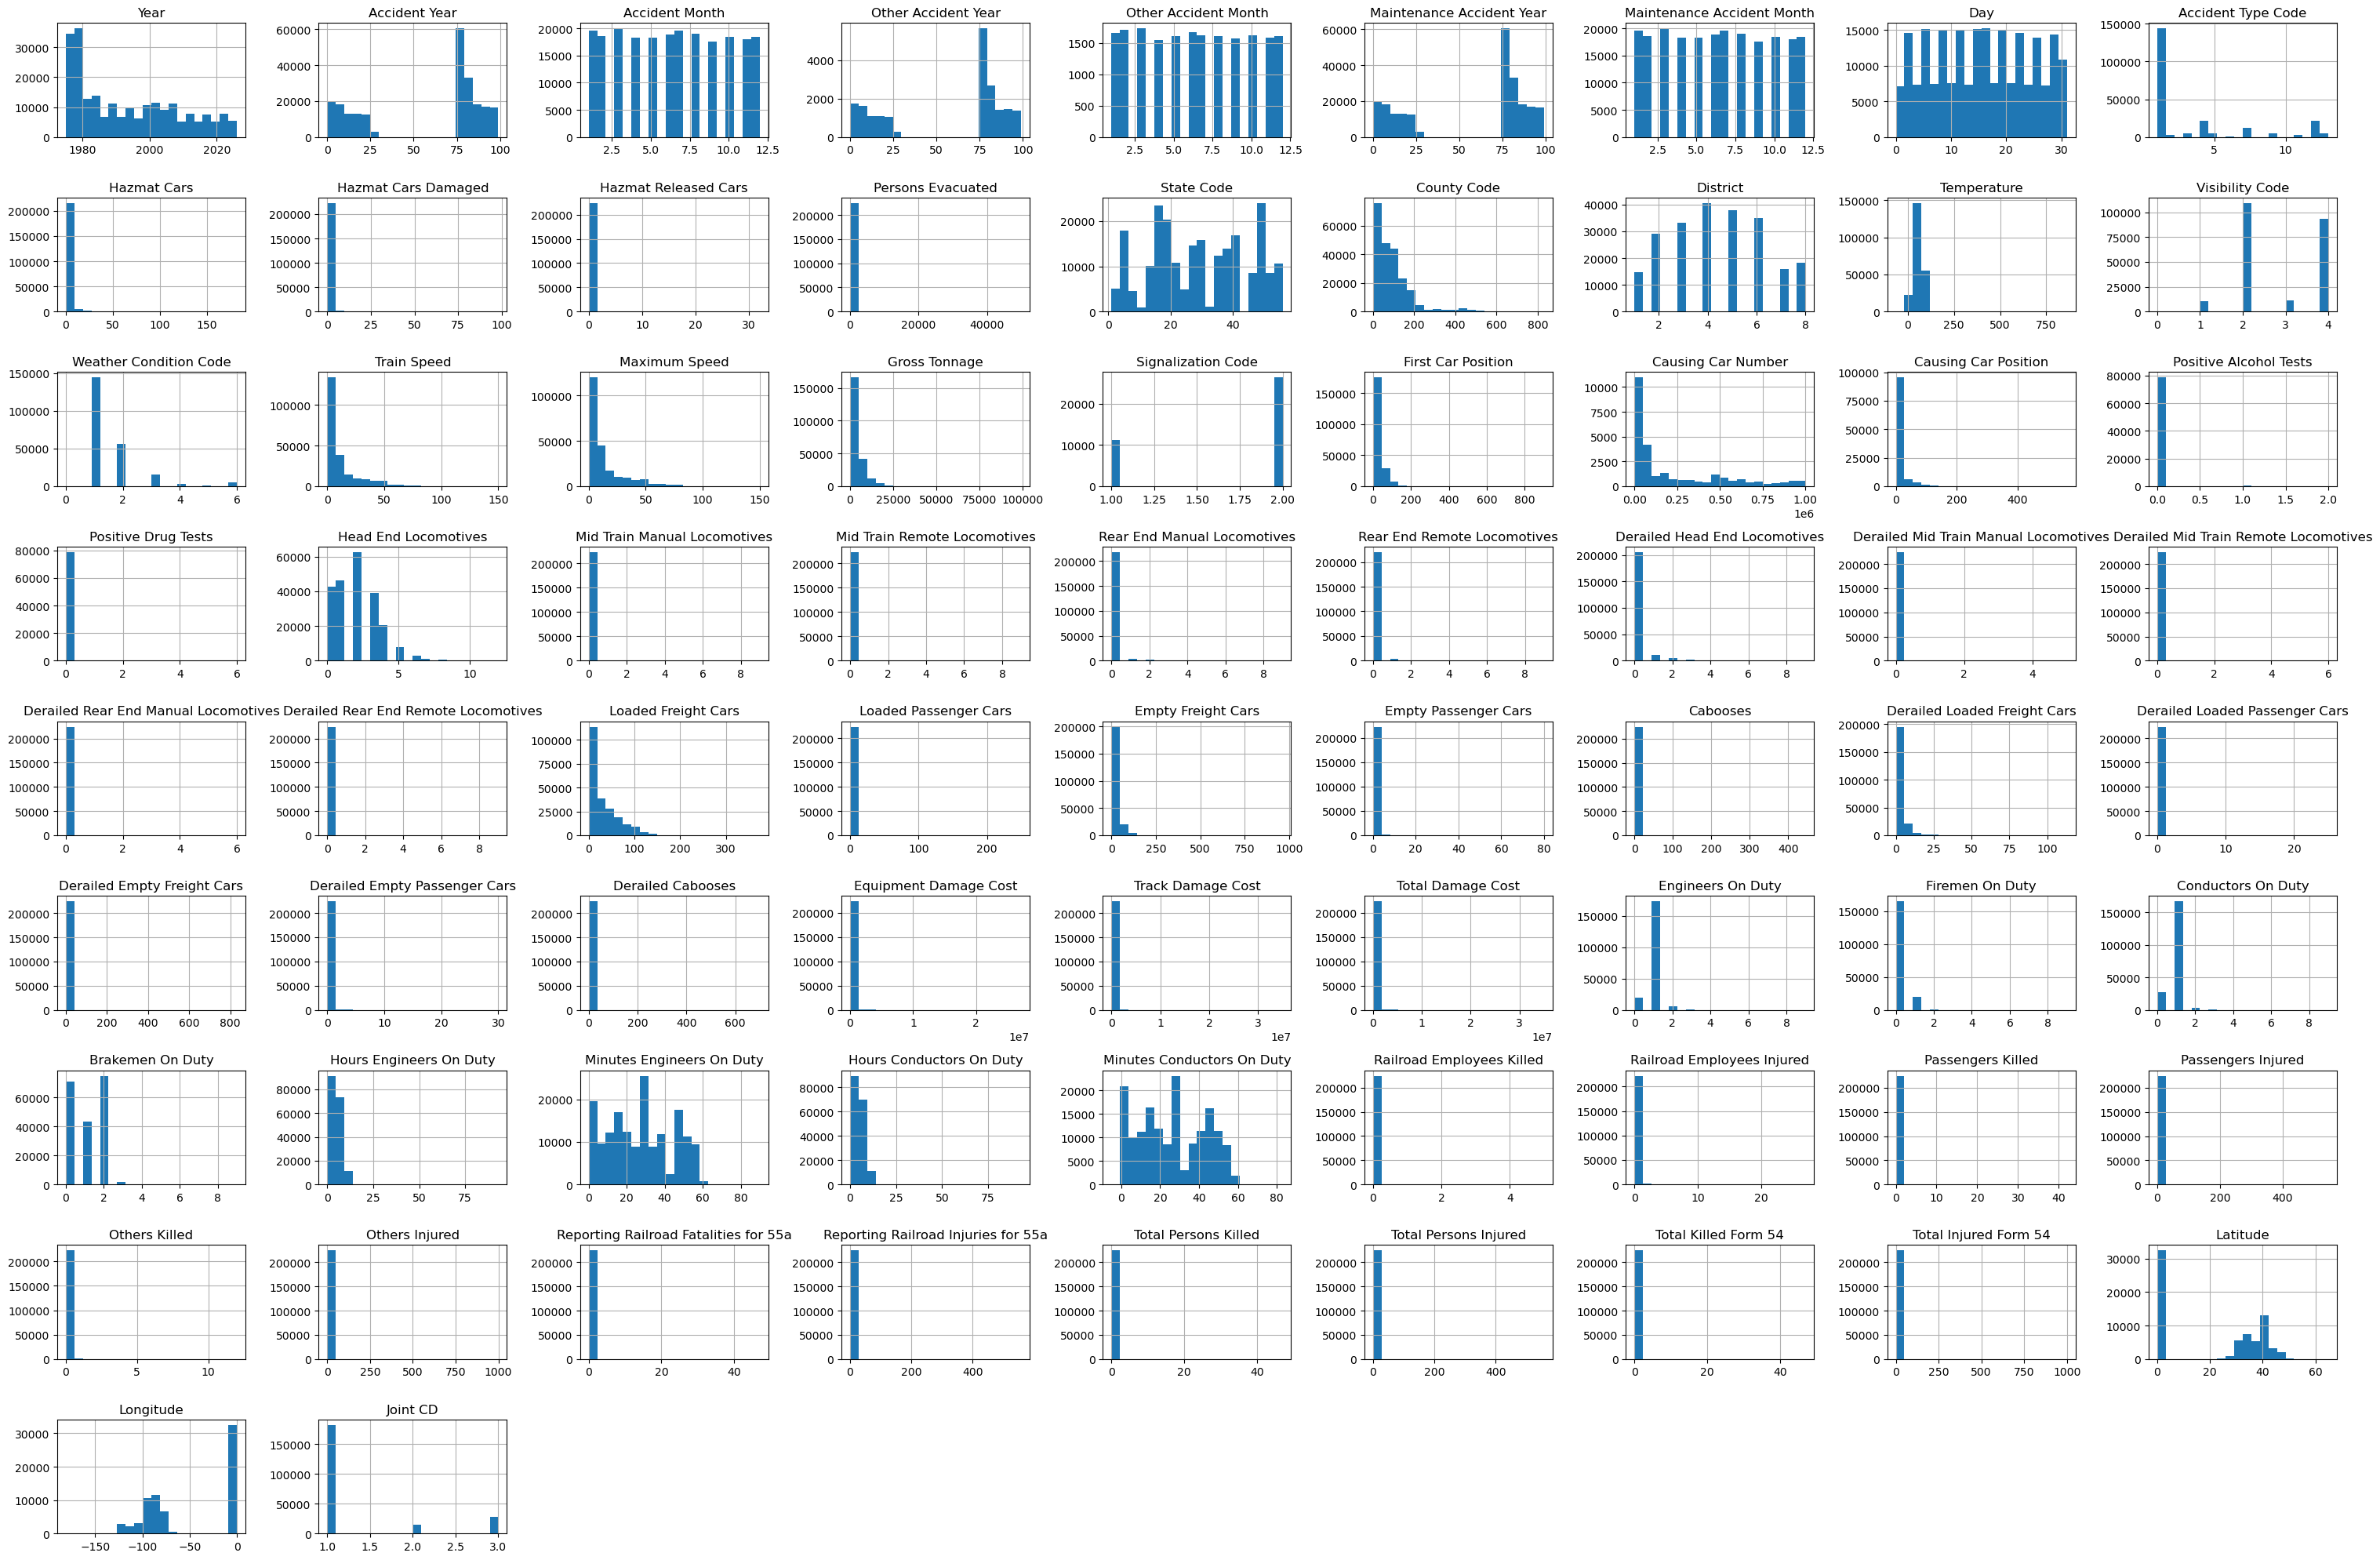

In [6]:
dist = df.hist(figsize=(30,20), bins = 20)
plt.tight_layout()
plt.show()

In [7]:
pd.set_option('display.max_rows', None)
missing_values = df.isnull().sum()
missing_values

Reporting Railroad Code                       0
Reporting Railroad Name                       3
Year                                          0
Accident Number                               0
PDF Link                                      4
Accident Year                                 0
Accident Month                                0
Other Railroad Code                      205206
Other Railroad Name                      205261
Other Accident Number                    205199
Other Accident Year                      205202
Other Accident Month                     205202
Maintenance Railroad Code                     3
Maintenance Railroad Name                    89
Maintenance Accident Number                   2
Maintenance Accident Year                     2
Maintenance Accident Month                    2
Grade Crossing ID                        212593
Day                                           0
Date                                          1
Time                                    

In [8]:
df.duplicated().sum()

np.int64(5)

In [9]:
df[df.duplicated(keep=False)] # Keeps all records that are considered duplicated

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,...,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
112390,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,NaN
112796,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,NaN
113981,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,NaN
114982,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,NaN
160267,CO,CHESAPEAKE & OHIO RAILWAY CO.,1978,AWV621,https://safetydata.fra.dot.gov/Officeofsafety/...,78,8,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class III,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN
160460,CO,CHESAPEAKE & OHIO RAILWAY CO.,1978,AWV621,https://safetydata.fra.dot.gov/Officeofsafety/...,78,8,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class III,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN
167639,BO,Baltimore And Ohio Railroad Company,1977,APA160,https://safetydata.fra.dot.gov/Officeofsafety/...,77,4,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Not Assigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN
169053,BO,Baltimore And Ohio Railroad Company,1977,APA160,https://safetydata.fra.dot.gov/Officeofsafety/...,77,4,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Not Assigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN
187566,WM,Western Maryland Railway,1976,AWM546,https://safetydata.fra.dot.gov/Officeofsafety/...,76,7,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class III,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN
197132,WM,Western Maryland Railway,1976,AWM546,https://safetydata.fra.dot.gov/Officeofsafety/...,76,7,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class III,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN


### Data Cleaning

In [10]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","")
df.columns.to_list()

['reportingrailroadcode',
 'reportingrailroadname',
 'year',
 'accidentnumber',
 'pdflink',
 'accidentyear',
 'accidentmonth',
 'otherrailroadcode',
 'otherrailroadname',
 'otheraccidentnumber',
 'otheraccidentyear',
 'otheraccidentmonth',
 'maintenancerailroadcode',
 'maintenancerailroadname',
 'maintenanceaccidentnumber',
 'maintenanceaccidentyear',
 'maintenanceaccidentmonth',
 'gradecrossingid',
 'day',
 'date',
 'time',
 'accidenttypecode',
 'accidenttype',
 'hazmatcars',
 'hazmatcarsdamaged',
 'hazmatreleasedcars',
 'personsevacuated',
 'subdivision',
 'divisioncode',
 'division',
 'station',
 'milepost',
 'statecode',
 'stateabbreviation',
 'statename',
 'countycode',
 'countyname',
 'district',
 'temperature',
 'visibilitycode',
 'visibility',
 'weatherconditioncode',
 'weathercondition',
 'tracktypecode',
 'tracktype',
 'trackname',
 'trackclass',
 'trackdensity',
 'traindirectioncode',
 'traindirection',
 'equipmenttypecode',
 'equipmenttype',
 'equipmentattended',
 'trainnum

In [11]:
print(f"# of Duplicated Values:", df.duplicated().sum())
df[df.duplicated()]

# of Duplicated Values: 5


,reportingrailroadcode,reportingrailroadname,year,accidentnumber,pdflink,accidentyear,accidentmonth,otherrailroadcode,otherrailroadname,otheraccidentnumber,...,reportingparentrailroadname,reportingrailroadholdingcompany,reportingrailroadindividualclass,reportingrailroadpassenger,reportingrailroadcommuter,reportingrailroadswitchingterminal,reportingrailroadtourist,reportingrailroadfreight,reportingrailroadshortline,location
112796,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,NaN
114982,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,NaN,NaN,NaN,...,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,NaN
160460,CO,CHESAPEAKE & OHIO RAILWAY CO.,1978,AWV621,https://safetydata.fra.dot.gov/Officeofsafety/...,78,8,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class III,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN
169053,BO,Baltimore And Ohio Railroad Company,1977,APA160,https://safetydata.fra.dot.gov/Officeofsafety/...,77,4,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Not Assigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN
197132,WM,Western Maryland Railway,1976,AWM546,https://safetydata.fra.dot.gov/Officeofsafety/...,76,7,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,Class III,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN


In [12]:
df = df.drop_duplicates()
print(f"# of Duplicated Values:", df.duplicated().sum())

# of Duplicated Values: 0


In [13]:
pd.set_option('display.max_rows', None)
missing_values = df.isnull().sum()
missing_values

reportingrailroadcode                      0
reportingrailroadname                      3
year                                       0
accidentnumber                             0
pdflink                                    4
accidentyear                               0
accidentmonth                              0
otherrailroadcode                     205201
otherrailroadname                     205256
otheraccidentnumber                   205194
otheraccidentyear                     205197
otheraccidentmonth                    205197
maintenancerailroadcode                    3
maintenancerailroadname                   89
maintenanceaccidentnumber                  2
maintenanceaccidentyear                    2
maintenanceaccidentmonth                   2
gradecrossingid                       212588
day                                        0
date                                       1
time                                       0
accidenttypecode                           0
accidentty

In [14]:
# Features with more then 10% of records being 'Null' were filter for analysis
missing_percent = df.isnull().sum() * 100 / len(df)
df2 = pd.DataFrame({'Percent Missing': missing_percent})
percent_miss_df = df2[df2['Percent Missing'] > 10.0]
percent_miss_df

,Percent Missing
otherrailroadcode,91.322614
otherrailroadname,91.347091
otheraccidentnumber,91.319499
otheraccidentyear,91.320834
otheraccidentmonth,91.320834
gradecrossingid,94.610123
subdivision,83.281190
divisioncode,19.871473
division,18.568841
milepost,13.164278


In [15]:
# df['name'].value_counts() # was used to analyze and determine solution
# Change data type found during exploration
df['district'] = df['district'].astype('str')
df['visibilitycode'] = df['visibilitycode'].astype('str')
df['weatherconditioncode'] = df['weatherconditioncode'].astype('str')
#===========================================================================================
# Handle "Nulls" intensionally
df['weatherconditioncode'] = df['weatherconditioncode'].replace('nan',np.nan)
df['visibilitycode'] = df['visibilitycode'].replace('nan',np.nan)
df['weatherconditioncode'] = df['weatherconditioncode'].replace('0.0',np.nan)
#==========================================================================================
# Filter out "confusing" values
df = df[df['accidenttype'] != 'Other (describe in narrative)']
df = df[(df['temperature'] < 100) & (df['temperature'] > -10)]
df = df[df['visibilitycode'] != 0.0]
df = df[df['loadedfreightcars'] <= 140]
df = df[df['loadedpassengercars'] <= 20]
df = df[df['emptyfreightcars'] <= 140]
df = df[df['emptypassengercars'] <= 20]
df = df[(df['trackclass'] != '.') & (df['trackclass'] != 'x') & (df['trackclass'] != 'O')]
df = df[df['engineersonduty'] <= 3.0]
df = df[df['firemenonduty'] <= 2.0]
df = df[df['conductorsonduty'] <= 3.0]
df = df[df['brakemenonduty'] <= 3.0]
#==========================================================================================
# Fixing Year features
drop_year = ['accidentyear']
df = df.drop(columns = drop_year, errors = 'ignore')
df = df.rename(columns={'year': 'accidentyear'})

### Column Description for Model Features
1) 'accidentyear': Year of accident.
2) 'accidentmonth': Month of accident.
3) 'accidenttype': Type of accident.
4) 'stateabbreviation': Two letter abbreviation of state.
5) 'district': FRA assigned geographical district.
6) 'temperature': Temperature recorded at time of accident, in Fahrenheit.
7) 'visibilitycode': Visibility code recorded at time of accident.
8) 'equipmenttype': Type of equipment consist.
9) 'weatherconditioncode': Weather condition code recorded at time of accident.
10) 'tracktype': Type of track.
11) 'passengerstransported': Yes/No if passengers were being transported. 
12) 'headendlocomotives': Number of head end locomotives.
13) 'traindirection': Direction of train.
14) 'trackclass': FRA Track Class.
15) 'engineersonduty': Number of engineers/operators on duty.
16) 'firemenonduty': Number of firemen on duty.
17) 'conductorsonduty': Number of conductors on duty.
18) 'brakemenonduty': Number of brakemen on duty.
19) 'loadedfreightcars': Number of loaded freight cars.
20) 'loadedpassengercars': Number of loaded passenger cars.
21) 'emptyfreightcars': Number of empty freight cars.
22) 'emptypassengercars': Number of empty passenger cars.
23) 'hazmatcars': Number of hazmat cars involved. 

##### Target Variables
1) 'totaldamagecost': Total cost of accident damage in dollars for all railroads involved in the incident.
2) 'totalpersonskilled': Total number of people killed in the accident for all railroads involved.
3) 'totalpersonsinjured': Total number of people injured in the accident for all railroads involved.

In [16]:
group = ['accidentyear',
         'accidentmonth', 
         'accidenttype',
         'stateabbreviation', 
         'district', 
         'temperature', 
         'visibilitycode', 
         'equipmenttype',
         'weatherconditioncode', 
         'tracktype', 
         'passengerstransported',
         'headendlocomotives', 
         'traindirection',
         'trackclass',
         'engineersonduty',
         'firemenonduty',
         'conductorsonduty',
         'brakemenonduty',
         'loadedfreightcars',
         'loadedpassengercars', 
         'emptyfreightcars', 
         'emptypassengercars',
         'hazmatcars',
         'totaldamagecost',
         'totalpersonskilled',
         'totalpersonsinjured']
#===========================================================================================
df = df[group]
df.head(3)

,accidentyear,accidentmonth,accidenttype,stateabbreviation,district,temperature,visibilitycode,equipmenttype,weatherconditioncode,tracktype,...,conductorsonduty,brakemenonduty,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,hazmatcars,totaldamagecost,totalpersonskilled,totalpersonsinjured
0,2011,8,Hwy-rail crossing,IL,4,77,2.0,Yard/switching,1.0,Yard,...,1.0,0.0,5,0,4,0,0,17368,0,0
1,2013,12,Other impacts,IL,4,11,4.0,Yard/switching,1.0,Yard,...,1.0,1.0,1,0,1,0,0,35372,0,0
2,2018,5,Derailment,IA,6,60,1.0,Freight Train,2.0,Main,...,1.0,1.0,2,0,78,0,0,13442,0,0


In [17]:
df.isnull().sum()

accidentyear                0
accidentmonth               0
accidenttype                0
stateabbreviation           0
district                    0
temperature                 0
visibilitycode            130
equipmenttype            3670
weatherconditioncode      247
tracktype                1871
passengerstransported    5403
headendlocomotives          0
traindirection           9975
trackclass               8694
engineersonduty             0
firemenonduty               0
conductorsonduty            0
brakemenonduty              0
loadedfreightcars           0
loadedpassengercars         0
emptyfreightcars            0
emptypassengercars          0
hazmatcars                  0
totaldamagecost             0
totalpersonskilled          0
totalpersonsinjured         0
dtype: int64

In [18]:
df = df.dropna()
df.shape

(153995, 26)

In [19]:
df.head(10)

,accidentyear,accidentmonth,accidenttype,stateabbreviation,district,temperature,visibilitycode,equipmenttype,weatherconditioncode,tracktype,...,conductorsonduty,brakemenonduty,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,hazmatcars,totaldamagecost,totalpersonskilled,totalpersonsinjured
0,2011,8,Hwy-rail crossing,IL,4,77,2.0,Yard/switching,1.0,Yard,...,1.0,0.0,5,0,4,0,0,17368,0,0
1,2013,12,Other impacts,IL,4,11,4.0,Yard/switching,1.0,Yard,...,1.0,1.0,1,0,1,0,0,35372,0,0
2,2018,5,Derailment,IA,6,60,1.0,Freight Train,2.0,Main,...,1.0,1.0,2,0,78,0,0,13442,0,0
4,2011,10,Derailment,IL,4,65,2.0,Yard/switching,2.0,Yard,...,1.0,0.0,12,0,8,0,0,66169,0,0
5,2023,10,Derailment,IA,6,51,4.0,Freight Train,1.0,Yard,...,1.0,1.0,91,0,50,0,43,203261,0,0
6,2024,7,Other impacts,IA,6,73,2.0,Cut of cars,2.0,Yard,...,0.0,2.0,0,0,3,0,0,39221,0,0
7,2014,5,Derailment,IL,4,60,4.0,Commuter Train - Pushing,3.0,Main,...,3.0,0.0,0,3,0,4,0,34900,0,0
8,2010,7,Derailment,IA,6,80,2.0,Freight Train,1.0,Industry,...,1.0,0.0,126,0,0,0,0,17231,0,0
10,2017,6,Derailment,IA,6,69,4.0,Freight Train,3.0,Main,...,1.0,0.0,105,0,33,0,28,426492,0,0
11,2011,3,Derailment,IL,4,34,2.0,Yard/switching,1.0,Yard,...,0.0,0.0,33,0,30,0,0,20910,0,0


## Calculating Risk Score

### Train Test Split

In [20]:
df['totaldamagecost'].describe()

count    1.539950e+05
mean     8.458428e+04
std      3.462237e+05
min      0.000000e+00
25%      9.025000e+03
50%      1.852700e+04
75%      4.913250e+04
max      3.153875e+07
Name: totaldamagecost, dtype: float64

In [21]:
df['totalpersonskilled'].describe()

count    153995.000000
mean          0.019390
std           0.243653
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          47.000000
Name: totalpersonskilled, dtype: float64

In [22]:
df['totalpersonsinjured'].describe()

count    153995.000000
mean          0.211987
std           3.928027
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         558.000000
Name: totalpersonsinjured, dtype: float64

In [23]:
# Split data
df_year_sorted = df.sort_values('accidentyear')
train_cutoff = df_year_sorted['accidentyear'].quantile(0.6)
val_cutoff = df_year_sorted['accidentyear'].quantile(0.8)
print(f"Train Cut Off:", train_cutoff)
print(f"Val Cut Off:", val_cutoff)
print("\n")
#===========================================================================================
df_train_time = df_year_sorted[df_year_sorted['accidentyear'] <= train_cutoff]
df_val_time = df_year_sorted[(df_year_sorted['accidentyear'] > train_cutoff) & (df_year_sorted['accidentyear'] <= val_cutoff)]
df_test_time = df_year_sorted[df_year_sorted['accidentyear'] > val_cutoff]
#===========================================================================================
print(f"Train Time:{df_train_time['accidentyear'].min(), df_train_time['accidentyear'].max()}")
print(f"Validation Time:{df_val_time['accidentyear'].min(), df_val_time['accidentyear'].max()}")
print(f"Test Time:{df_test_time['accidentyear'].min(), df_test_time['accidentyear'].max()}")

Train Cut Off: 1997.0
Val Cut Off: 2011.0


Train Time:(1975, 1997)
Validation Time:(1998, 2011)
Test Time:(2012, 2026)


In [24]:
threshold_year = {1975:1750,1976:1750,1977:2300,1978:2300,1979:2900,1980:2900,1981:3700,1982:3700,
                  1983:4500,1984:4500,1985:4900,1986:4900,1987:5200,1988:5200,1989:5700,1990:5700,
                  1991:6300,1992:6300,1993:6300,1994:6300,1995:6300,1996:6300,1997:6500,1998:6600,
                  1999:6600,2000:6600,2001:6600,2002:6700,2003:6700,2004:6700,2005:6700,2006:7700,
                  2007:8200,2008:8500,2009:8900,2010:9200,2011:9400,2012:9500,2013:9900,2014:10500,
                  2015:10500,2016:10500,2017:10700,2018:10889,2019:10889,2020:10967,2021:11200,2022:11200,
                  2023:11200,2024:12000,2025:12400,2026:12600}
#===========================================================================================
df_train_time['threshold'] = df_train_time['accidentyear'].map(threshold_year)
df_val_time['threshold'] = df_val_time['accidentyear'].map(threshold_year)
df_test_time['threshold'] = df_test_time['accidentyear'].map(threshold_year)
#===========================================================================================
df_train_time['damage_ratio'] = df_train_time['totaldamagecost']/df_train_time['threshold']
df_val_time['damage_ratio'] = df_val_time['totaldamagecost']/df_val_time['threshold']
df_test_time['damage_ratio'] = df_test_time['totaldamagecost']/df_test_time['threshold']
#===========================================================================================
display(df_train_time[['accidentyear','totaldamagecost','threshold','damage_ratio']].head(3))
print('\n')
display(df_val_time[['accidentyear','totaldamagecost','threshold','damage_ratio']].head(3))
print('\n')
display(df_test_time[['accidentyear','totaldamagecost','threshold','damage_ratio']].head(3))

C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\3642991287.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_time['threshold'] = df_train_time['accidentyear'].map(threshold_year)
C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\3642991287.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_time['threshold'] = df_val_time['accidentyear'].map(threshold_year)
C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\3642991287.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy 

,accidentyear,totaldamagecost,threshold,damage_ratio
180487,1975,14325,1750,8.185714
175641,1975,1862,1750,1.064000
175639,1975,8357,1750,4.775429


,accidentyear,totaldamagecost,threshold,damage_ratio
42002,1998,558795,6600,84.665909
41999,1998,103639,6600,15.702879
41990,1998,28447,6600,4.310152


,accidentyear,totaldamagecost,threshold,damage_ratio
47356,2012,735102,9500,77.379158
6833,2012,14546,9500,1.531158
221606,2012,119600,9500,12.589474


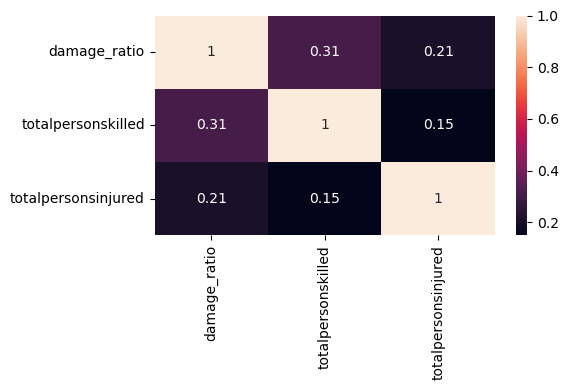

In [25]:
risk_ft = ['damage_ratio','totalpersonskilled', 'totalpersonsinjured']
plt.figure(figsize = (6,4))
heat_data = df_train_time[risk_ft].corr(numeric_only=True)
ax = sns.heatmap(heat_data, annot = True)
plt.tight_layout()

In [26]:
risk_ft = ['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured']
scaler = StandardScaler()
train_scaled = scaler.fit_transform(df_train_time[risk_ft])
val_scaled = scaler.transform(df_val_time[risk_ft])
test_scaled = scaler.transform(df_test_time[risk_ft])
#===========================================================================================
pca = PCA(n_components=1)
pca.fit(train_scaled)
#===========================================================================================
loading = np.abs(pca.components_[0])
weights = loading/loading.sum()
weight_series = pd.Series(weights, index=risk_ft)
print(weight_series)

damage_ratio           0.368638
totalpersonskilled     0.346178
totalpersonsinjured    0.285184
dtype: float64


In [27]:
df_train_time['risk_score'] = (train_scaled * weights).sum(axis=1)
df_val_time['risk_score'] = (val_scaled * weights).sum(axis=1)
df_test_time['risk_score'] = (test_scaled * weights).sum(axis=1)

C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\4010367082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_time['risk_score'] = (train_scaled * weights).sum(axis=1)
C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\4010367082.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_time['risk_score'] = (val_scaled * weights).sum(axis=1)
C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\4010367082.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

In [28]:
print("Train Top 5")
display(df_train_time[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured','risk_score']].sort_values('risk_score',ascending=False).head(5))
print("\n")
print("Validation Top 5")
display(df_val_time[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured','risk_score']].sort_values('risk_score',ascending=False).head(5))
print("\n")
print("Test Top 5")
display(df_test_time[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured','risk_score']].sort_values('risk_score',ascending=False).head(5))

Train Top 5


,damage_ratio,totalpersonskilled,totalpersonsinjured,risk_score
92490,1804.666667,47,103,82.590195
106255,2435.807692,16,177,51.687881
149844,14.285217,0,558,36.323527
149822,14.285217,0,558,36.323527
182541,23.448571,0,485,31.639963




Validation Top 5


,damage_ratio,totalpersonskilled,totalpersonsinjured,risk_score
74560,1537.782471,25,61,48.842803
59922,1466.204545,11,50,29.169732
215933,932.838511,6,101,21.702226
193245,1625.701493,4,0,17.979946
194243,1625.701493,4,0,17.979946




Test Top 5


,damage_ratio,totalpersonskilled,totalpersonsinjured,risk_score
198805,3003.690857,8,241,49.844962
15104,2414.112150,3,90,28.771703
32455,47.647789,0,385,25.316326
49127,1966.004554,3,83,24.768102
1184,1594.725595,2,136,23.968307


In [29]:
print("Train Description")
display(df_train_time['risk_score'].describe())
print("\n")
print("Validation Description")
print(df_val_time['risk_score'].describe())
print("\n")
print("Test Description")
print(df_test_time['risk_score'].describe())

Train Description


count    9.322300e+04
mean     1.463418e-17
std      6.992346e-01
min     -1.444655e-01
25%     -1.300089e-01
50%     -1.166320e-01
75%     -6.605238e-02
max      8.259019e+01
Name: risk_score, dtype: float64



Validation Description
count    32123.000000
mean         0.009200
std          0.595510
min         -0.143284
25%         -0.129764
50%         -0.114333
75%         -0.058394
max         48.842803
Name: risk_score, dtype: float64


Test Description
count    28649.000000
mean         0.014560
std          0.705526
min         -0.144465
25%         -0.129712
50%         -0.113010
75%         -0.055297
max         49.844962
Name: risk_score, dtype: float64


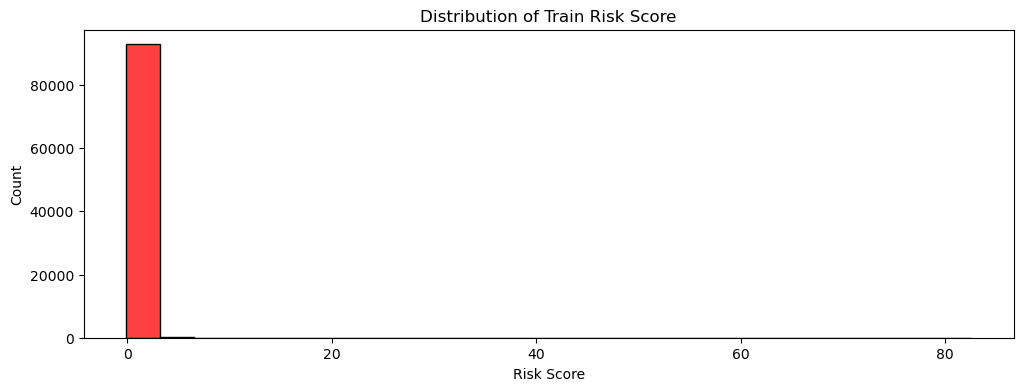

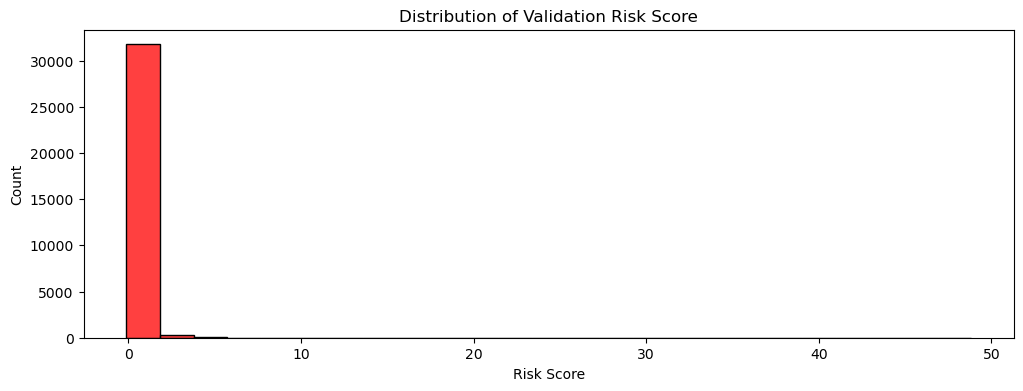

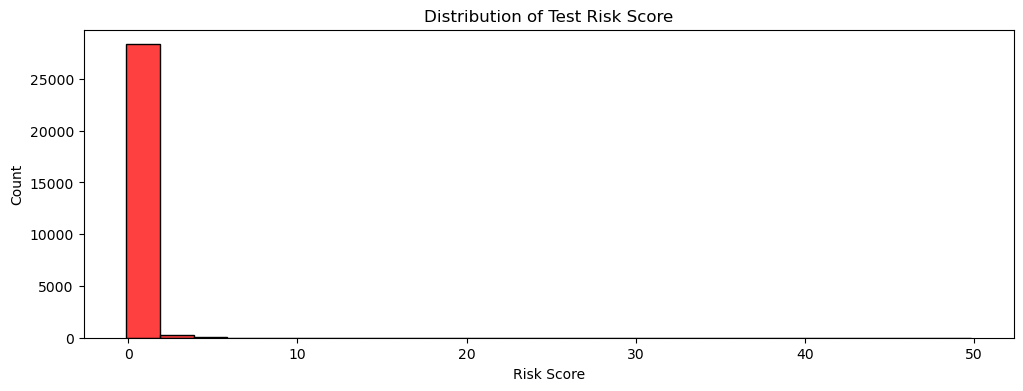

In [30]:
plt.figure(figsize=(12,4))
sns.histplot(data = df_train_time, x='risk_score', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Train Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()
#===========================================================================================
plt.figure(figsize=(12,4))
sns.histplot(data = df_val_time, x='risk_score', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Validation Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()
#===========================================================================================
plt.figure(figsize=(12,4))
sns.histplot(data = df_test_time, x='risk_score', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Test Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()

In [31]:
print("Train Description")
print(skew(df_train_time['risk_score']))
print("\n")
print("Validation Description")
print(skew(df_val_time['risk_score']))
print("\n")
print("Test Description")
print(skew(df_test_time['risk_score']))

Train Description
37.34842887331486


Validation Description
29.17953231908812


Test Description
28.00061808186526


### Power Transformation

In [32]:
transformer = PowerTransformer(method='yeo-johnson')
df_train_time['risk_score_yeo'] = transformer.fit_transform(df_train_time[['risk_score']])
df_val_time['risk_score_yeo'] = transformer.transform(df_val_time[['risk_score']])
df_test_time['risk_score_yeo'] = transformer.transform(df_test_time[['risk_score']])

C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\1296834791.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_time['risk_score_yeo'] = transformer.fit_transform(df_train_time[['risk_score']])
C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\1296834791.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_time['risk_score_yeo'] = transformer.transform(df_val_time[['risk_score']])
C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\1296834791.py:4: SettingWithCopyWarning: 
A value is trying to

Text(0.5, 1.0, 'Probability Plot on Test After Yeo-Johnson')

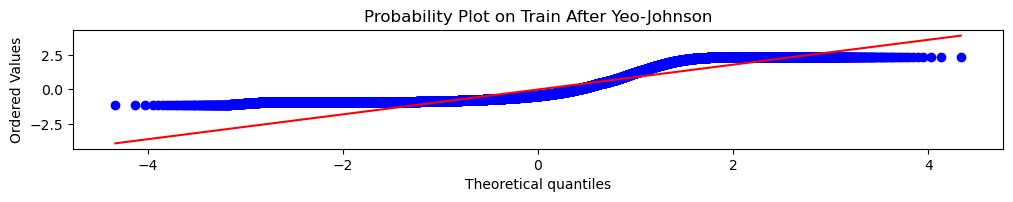

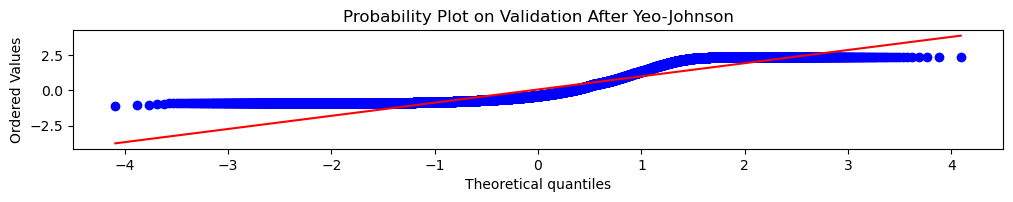

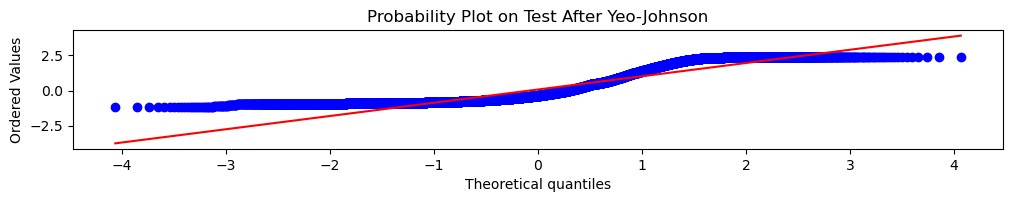

In [33]:
fig = plt.figure(figsize=(12,4))
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
prob1 = stats.probplot(df_train_time['risk_score_yeo'], dist='norm', plot=ax1)
ax1.set_title('Probability Plot on Train After Yeo-Johnson')
#===========================================================================================
fig = plt.figure(figsize=(12,4))
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
prob1 = stats.probplot(df_val_time['risk_score_yeo'], dist='norm', plot=ax1)
ax1.set_title('Probability Plot on Validation After Yeo-Johnson')
#===========================================================================================
fig = plt.figure(figsize=(12,4))
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
prob1 = stats.probplot(df_test_time['risk_score_yeo'], dist='norm', plot=ax1)
ax1.set_title('Probability Plot on Test After Yeo-Johnson')

In [34]:
print('Train Count')
print(df_train_time['risk_score_yeo'].value_counts().head(5))
print(df_train_time['risk_score_yeo'].value_counts().sort_index(ascending=False).head(5))
print('\n')
print('Validation Count')
print(df_val_time['risk_score_yeo'].value_counts().head(5))
print(df_val_time['risk_score_yeo'].value_counts().sort_index(ascending=False).head(5))
print('\n')
print('Test Count')
print(df_test_time['risk_score_yeo'].value_counts().head(5))
print(df_test_time['risk_score_yeo'].value_counts().sort_index(ascending=False).head(5))

Train Count
risk_score_yeo
-0.731762    275
-0.873532    241
-0.847763    223
-0.930204    221
-0.857958    219
Name: count, dtype: int64
risk_score_yeo
2.352817    1
2.352817    1
2.352817    2
2.352817    2
2.352817    2
Name: count, dtype: int64


Validation Count
risk_score_yeo
-0.834571    71
-0.684499    45
-0.896584    42
-0.865434    41
-0.541281    39
Name: count, dtype: int64
risk_score_yeo
2.352817    1
2.352817    1
2.352817    1
2.352817    2
2.352817    2
Name: count, dtype: int64


Test Count
risk_score_yeo
-0.847763    35
-0.866264    29
-0.685808    23
-0.750809    23
-0.798926    21
Name: count, dtype: int64
risk_score_yeo
2.352817    1
2.352817    1
2.352817    1
2.352817    1
2.352817    2
Name: count, dtype: int64


In [35]:
print("Train Description")
print(skew(df_train_time['risk_score_yeo']))
print("\n")
print("Validation Description")
print(skew(df_val_time['risk_score_yeo']))
print("\n")
print("Test Description")
print(skew(df_test_time['risk_score_yeo']))

Train Description
1.1438844746715804


Validation Description
1.0474247000220682


Test Description
0.9860043476267282


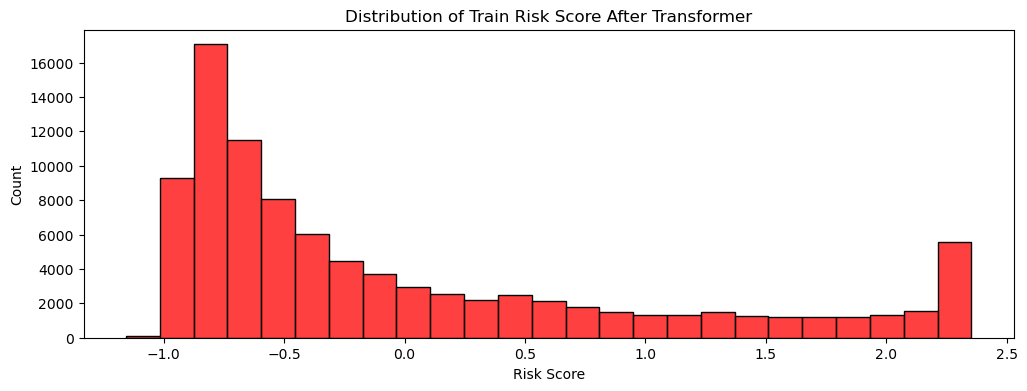

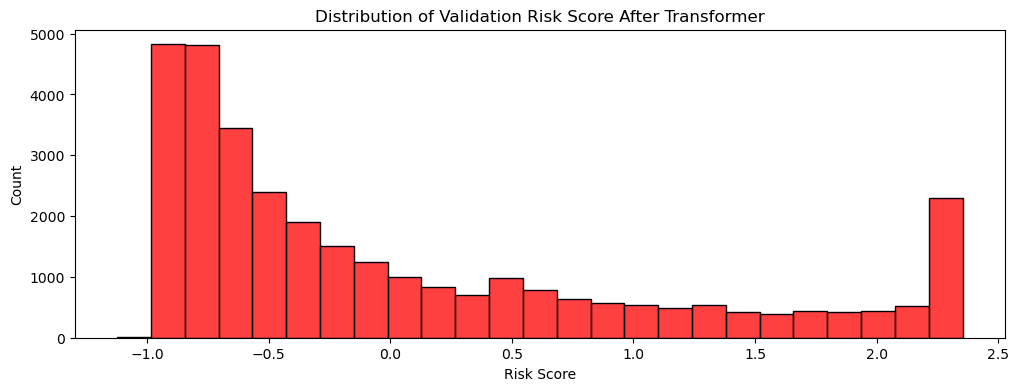

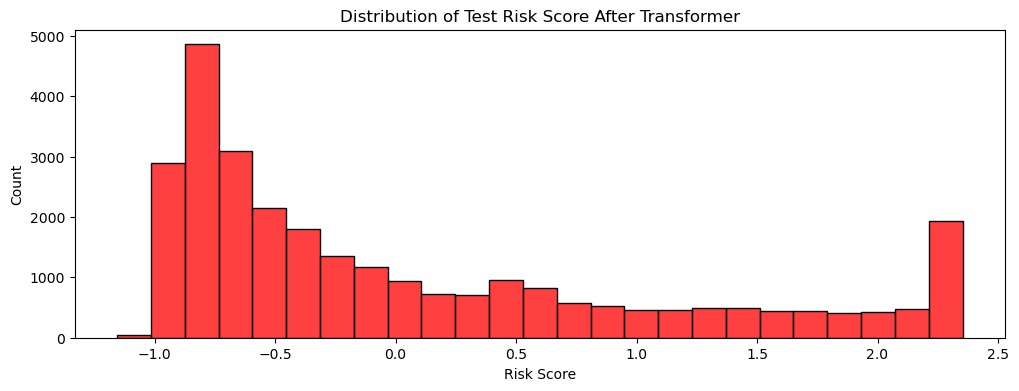

In [36]:
plt.figure(figsize=(12,4))
sns.histplot(data = df_train_time, x='risk_score_yeo', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Train Risk Score After Transformer')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()
#===========================================================================================
plt.figure(figsize=(12,4))
sns.histplot(data = df_val_time, x='risk_score_yeo', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Validation Risk Score After Transformer')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()
#===========================================================================================
plt.figure(figsize=(12,4))
sns.histplot(data = df_test_time, x='risk_score_yeo', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Test Risk Score After Transformer')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()

### Risk Category

In [37]:
df_train_time['risk_category'], bin_edges = pd.qcut(df_train_time['risk_score_yeo'], q=2, labels = ['Low Severity', 'High Severity'], retbins=True) # retbins: Returns bins and labels
#===========================================================================================
df_val_time['risk_category'] = pd.cut(df_val_time['risk_score_yeo'], bins=bin_edges, labels = ['Low Severity', 'High Severity'], include_lowest=True) # include_lowest: Keeps the lowest value in
df_test_time['risk_category'] = pd.cut(df_test_time['risk_score_yeo'], bins=bin_edges, labels = ['Low Severity', 'High Severity'], include_lowest=True)

C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\3582018591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_time['risk_category'], bin_edges = pd.qcut(df_train_time['risk_score_yeo'], q=2, labels = ['Low Severity', 'High Severity'], retbins=True) # retbins: Returns bins and labels
C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\3582018591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_time['risk_category'] = pd.cut(df_val_time['risk_score_yeo'], bins=bin_edges, labels = ['Low Sev

In [38]:
print(df_train_time['risk_category'].value_counts())
print("\n")
print("Validation Category Count")
print(df_val_time['risk_category'].value_counts())
print("\n")
print("Test Category Count")
print(df_test_time['risk_category'].value_counts())

risk_category
Low Severity     46612
High Severity    46611
Name: count, dtype: int64


Validation Category Count
risk_category
High Severity    16841
Low Severity     15282
Name: count, dtype: int64


Test Category Count
risk_category
High Severity    15449
Low Severity     13200
Name: count, dtype: int64


In [39]:
print("Bin Thresholds")
bin_edges = [round(bin,3) for bin in bin_edges]
print(bin_edges)

Bin Thresholds
[np.float64(-1.156), np.float64(-0.443), np.float64(2.353)]


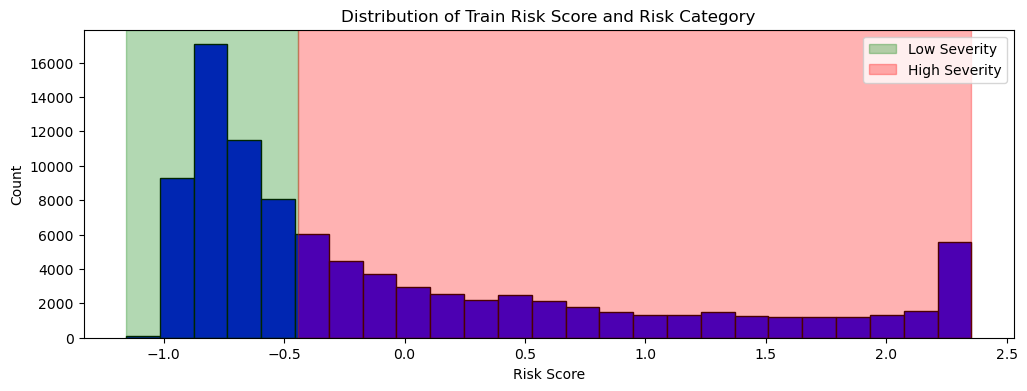

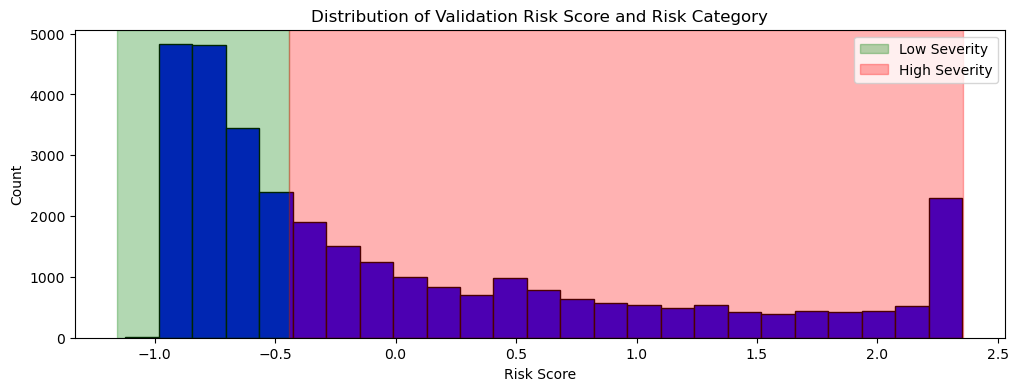

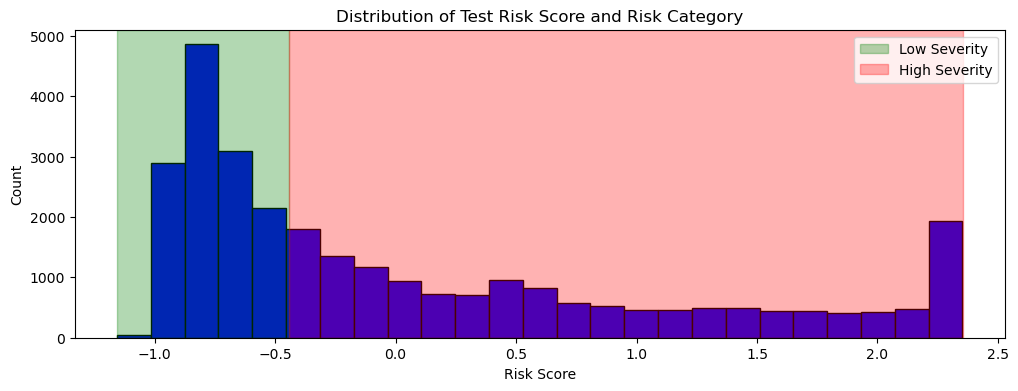

In [40]:
def plot_bins(data, title, bins):
    plt.figure(plt.figure(figsize=(12,4)))
    plt.hist(data, bins=25, color='blue', edgecolor='black')
    plt.axvspan(bins[0], bins[1], color='green', alpha=0.3, label='Low Severity')
    plt.axvspan(bins[1], bins[2], color='red', alpha=0.3, label='High Severity')
    plt.title(title)
    plt.xlabel('Risk Score')
    plt.ylabel('Count')
    plt.legend()
    plt.show
#===========================================================================================
plot_bins(df_train_time['risk_score_yeo'],"Distribution of Train Risk Score and Risk Category",bin_edges)
plot_bins(df_val_time['risk_score_yeo'],"Distribution of Validation Risk Score and Risk Category",bin_edges)
plot_bins(df_test_time['risk_score_yeo'],"Distribution of Test Risk Score and Risk Category",bin_edges)

In [41]:
df_train_time.groupby('risk_category')[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured']].describe()

C:\Users\thilt\AppData\Local\Temp\ipykernel_33432\3965795046.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train_time.groupby('risk_category')[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured']].describe()


damage_ratio                                                 \
                     count       mean        std  min       25%       50%   
risk_category                                                               
Low Severity       46612.0   1.961947   0.700748  0.0  1.368966  1.826087   
High Severity      46611.0  24.581297  63.877540  0.0  4.793651  8.047619   

                                      totalpersonskilled            ...       \
                     75%          max              count      mean  ...  75%   
risk_category                                                       ...        
Low Severity    2.478261     3.515789            46612.0  0.000000  ...  0.0   
High Severity  19.076451  2435.807692            46611.0  0.038296  ...  0.0   

                    totalpersonsinjured                                     \
                max               count      mean       std  min  25%  50%   
risk_category                                                                
Low Severity    0.0             46612.0  0.000000  0.000000  0.0  0.0  0.0   
High Severity  47.0             46611.0  0.437365  6.182659  0.0  0.0  0.0   

                           
               75%    max  
risk_category              
Low Severity   0.0    0.0  
High Severity  0.0  558.0  

[2 rows x 24 columns]

### EDA

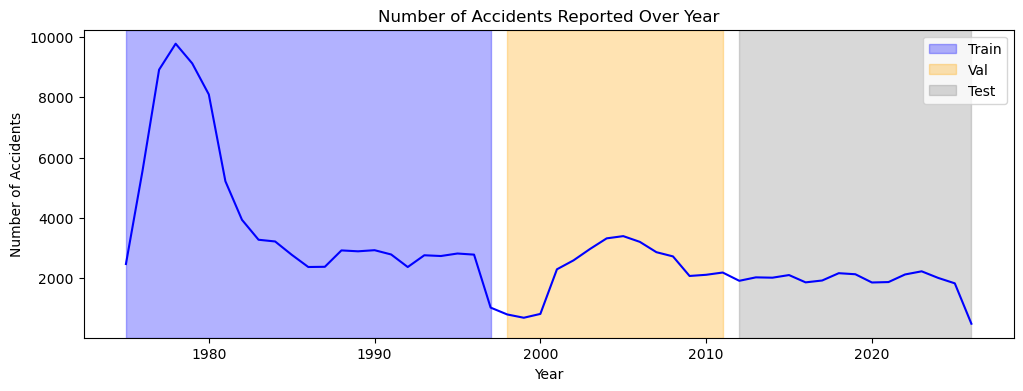

In [42]:
plt.figure(figsize=(12, 4))
accident_year = df.groupby('accidentyear').size()
sns.lineplot(x=accident_year.index, y=accident_year.values, color="blue")
plt.axvspan(1975, 1997, color='blue', alpha=0.3, label='Train')
plt.axvspan(1998, 2011, color='orange', alpha=0.3, label='Val')
plt.axvspan(2012, 2026, color='grey', alpha=0.3, label='Test')
plt.title('Number of Accidents Reported Over Year')
plt.ylabel('Number of Accidents')
plt.xlabel('Year')
plt.legend()
plt.show()

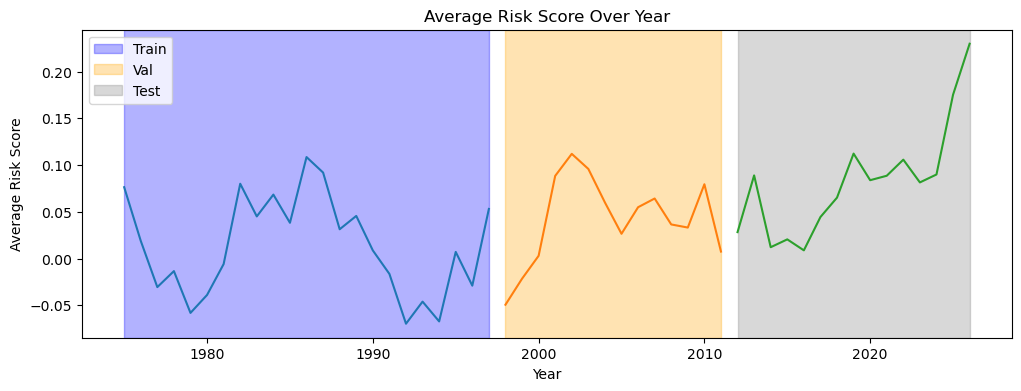

In [43]:
train_trend = df_train_time.groupby('accidentyear')['risk_score_yeo'].mean()
val_trend = df_val_time.groupby('accidentyear')['risk_score_yeo'].mean()
test_trend = df_test_time.groupby('accidentyear')['risk_score_yeo'].mean()
#===========================================================================================
plt.figure(figsize=(12, 4))
sns.lineplot(x=train_trend.index, y=train_trend.values)
sns.lineplot(x=val_trend.index, y=val_trend.values)
sns.lineplot(x=test_trend.index, y=test_trend.values)
plt.axvspan(1975, 1997, color='blue', alpha=0.3, label='Train')
plt.axvspan(1998, 2011, color='orange', alpha=0.3, label='Val')
plt.axvspan(2012, 2026, color='grey', alpha=0.3, label='Test')
plt.title('Average Risk Score Over Year')
plt.ylabel('Average Risk Score')
plt.xlabel('Year')
plt.legend()
plt.show()

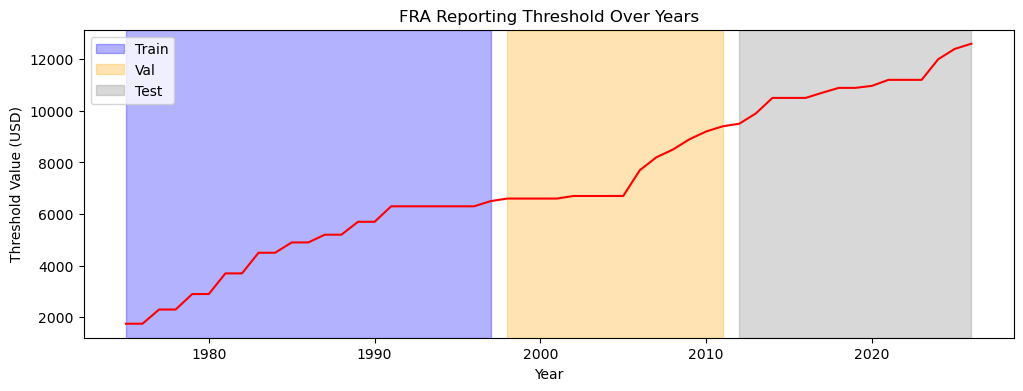

In [44]:
year = list(range(1975,2027))
threshold = [1750,1750,2300,2300,2900,2900,3700,3700,4500,4500,4900,4900,5200,5200,5700,5700,6300,6300,6300,6300,6300,6300,6500,6600,6600,6600,6600,6700,6700,6700,6700,7700,8200,8500,8900,9200,9400,9500,9900,10500,10500,10500,10700,10889,10889,10967,11200,11200,11200,12000,12400,12600]
#===========================================================================================
plt.figure(figsize=(12, 4))
plt.plot(year,threshold,color='red')
plt.axvspan(1975, 1997, color='blue', alpha=0.3, label='Train')
plt.axvspan(1998, 2011, color='orange', alpha=0.3, label='Val')
plt.axvspan(2012, 2026, color='grey', alpha=0.3, label='Test')
plt.title("FRA Reporting Threshold Over Years")
plt.xlabel("Year")
plt.ylabel("Threshold Value (USD)")
plt.legend()
plt.show()

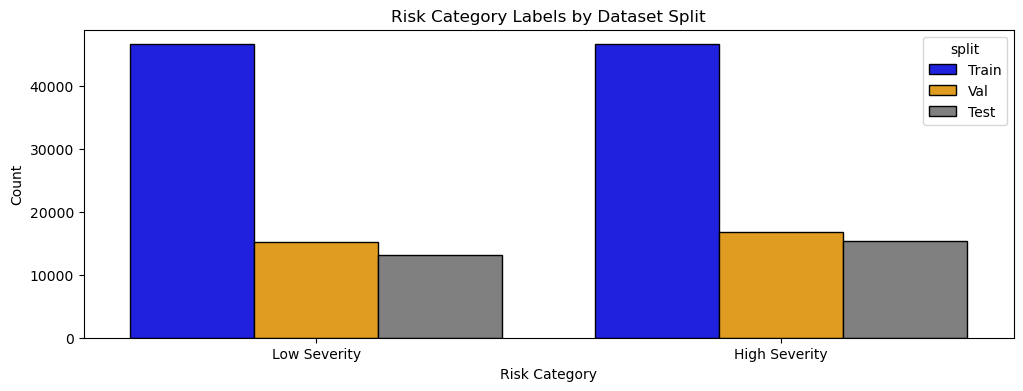

In [45]:
x_order = ['Low Severity','High Severity']
combined = pd.concat([df_train_time[['risk_category']].assign(split="Train"),
                      df_val_time[['risk_category']].assign(split="Val"),
                       df_test_time[['risk_category']].assign(split="Test")], ignore_index=True)
#===========================================================================================
plt.figure(figsize=(12,4))
sns.countplot(combined, x='risk_category', hue = 'split', edgecolor = 'black', order = x_order, palette = ['blue','orange','grey'])
plt.title('Risk Category Labels by Dataset Split')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.show()

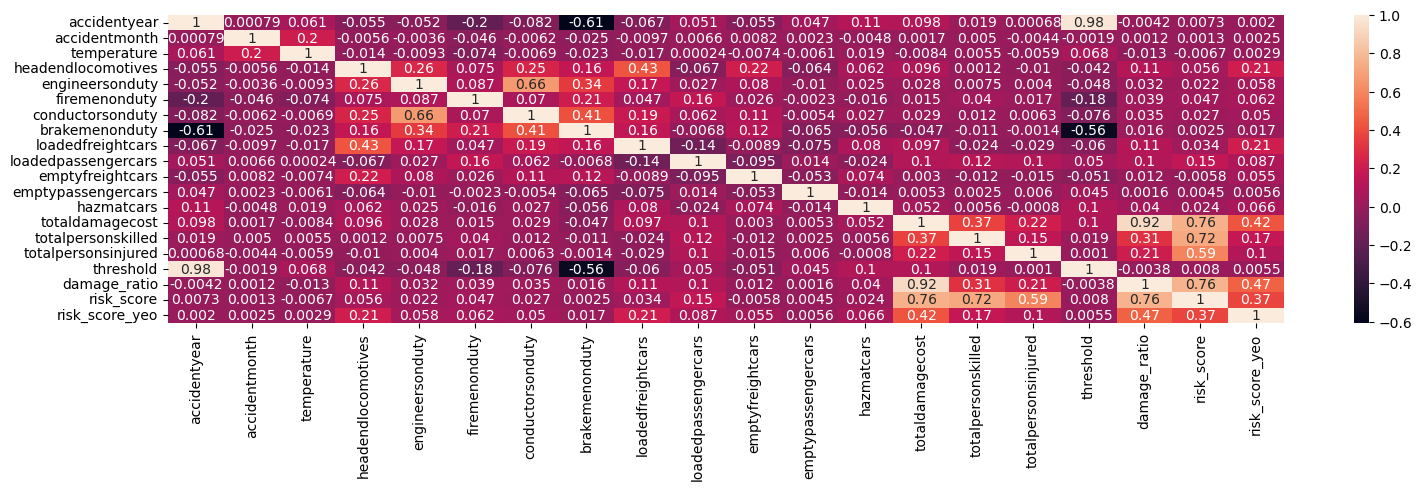

In [46]:
plt.figure(figsize=(18,4))
plt.tight_layout
sns.heatmap(df_train_time.corr(numeric_only=True), annot=True)
plt.show()

In [47]:
cat = df_train_time.select_dtypes(include='object').columns
print(cat)
print('\n')
print("Categorical Number of Unique Values")
for c in cat:
    print(c,':',df_train_time[c].nunique())
#===========================================================================================
print('\n')
cat_list = ['accidenttype','district','visibilitycode','equipmenttype','weatherconditioncode','tracktype','trackclass']
for c in cat_list:
    print(c)
    print(df_train_time.groupby(c)['risk_score_yeo'].mean().sort_values())
    print("\n")

Index(['accidenttype', 'stateabbreviation', 'district', 'visibilitycode',
       'equipmenttype', 'weatherconditioncode', 'tracktype',
       'passengerstransported', 'traindirection', 'trackclass'],
      dtype='object')


Categorical Number of Unique Values
accidenttype : 12
stateabbreviation : 50
district : 8
visibilitycode : 4
equipmenttype : 9
weatherconditioncode : 6
tracktype : 4
passengerstransported : 2
traindirection : 4
trackclass : 8


accidenttype
accidenttype
Other impacts            -0.360014
Side collision           -0.238361
Raking collision         -0.176580
Explosion-detonation     -0.092887
Obstruction              -0.016169
Derailment               -0.008055
Fire/violent rupture     -0.007191
Broken train collision    0.204842
Rear end collision        0.535110
Hwy-rail crossing         0.792314
Head on collision         0.822953
RR grade crossing         0.891320
Name: risk_score_yeo, dtype: float64


district
district
4   -0.119792
2   -0.059856
1   -0.032546
5  

In [48]:
drop_list = ['totaldamagecost', 'totalpersonskilled', 'totalpersonsinjured','threshold','damage_ratio','risk_score']
df_train_time = df_train_time.drop(columns = drop_list, axis=1)
df_val_time = df_val_time.drop(columns = drop_list, axis=1)
df_test_time = df_test_time.drop(columns = drop_list, axis=1)
df_train_time.columns.to_list()

['accidentyear',
 'accidentmonth',
 'accidenttype',
 'stateabbreviation',
 'district',
 'temperature',
 'visibilitycode',
 'equipmenttype',
 'weatherconditioncode',
 'tracktype',
 'passengerstransported',
 'headendlocomotives',
 'traindirection',
 'trackclass',
 'engineersonduty',
 'firemenonduty',
 'conductorsonduty',
 'brakemenonduty',
 'loadedfreightcars',
 'loadedpassengercars',
 'emptyfreightcars',
 'emptypassengercars',
 'hazmatcars',
 'risk_score_yeo',
 'risk_category']

### Preparing Datasets

In [49]:
# KNN Target Variable
y_train_knn = df_train_time['risk_category']
y_val_knn = df_val_time['risk_category']
y_test_knn = df_test_time['risk_category']
#===========================================================================================
# Linear Regression Variable
y_train_lin = df_train_time['risk_score_yeo']
y_val_lin = df_val_time['risk_score_yeo']
y_test_lin = df_test_time['risk_score_yeo']
#===========================================================================================
# Splitting for modeling
X_train = df_train_time.drop(columns=['risk_category','risk_score_yeo'])
X_val = df_val_time.drop(columns=['risk_category','risk_score_yeo'])
X_test = df_test_time.drop(columns=['risk_category','risk_score_yeo'])

In [50]:
print(f"Train Time Order: {df_train_time['accidentyear'].is_monotonic_increasing}")
print(f"Validation Time Order: {df_val_time['accidentyear'].is_monotonic_increasing}")
print(f"Test Time Order: {df_test_time['accidentyear'].is_monotonic_increasing}")

Train Time Order: True
Validation Time Order: True
Test Time Order: True


In [51]:
categorical_cols = X_train.select_dtypes(include=['object']).columns # Subset categorical features

X_train[categorical_cols] = X_train[categorical_cols].astype(str)
X_val[categorical_cols] = X_val[categorical_cols].astype(str)
X_test[categorical_cols] = X_test[categorical_cols].astype(str)

encode = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encode = encode.fit_transform(X_train[categorical_cols])
val_encode = encode.transform(X_val[categorical_cols])
test_encode = encode.transform(X_test[categorical_cols])
#===========================================================================================
# Created an array. Claude AI was used to help trouble shoot how to return a dataframe. 
train_encode_df = pd.DataFrame(train_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_train.index)
val_encode_df = pd.DataFrame(val_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_val.index)
test_encode_df = pd.DataFrame(test_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_test.index)
#===========================================================================================
X_train=X_train.drop(columns=categorical_cols).join(train_encode_df)
X_val=X_val.drop(columns=categorical_cols).join(val_encode_df)
X_test=X_test.drop(columns=categorical_cols).join(test_encode_df)

In [52]:
continuous_cols = ['accidentyear','hazmatcars','temperature','engineersonduty','firemenonduty','conductorsonduty','brakemenonduty','headendlocomotives','loadedfreightcars','loadedpassengercars','emptyfreightcars','emptypassengercars']
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols]) 

In [53]:
X_train['month_sin'] = np.sin(X_train['accidentmonth'] * (2 * np.pi / 12))
X_train['month_cos'] = np.cos(X_train['accidentmonth'] * (2 * np.pi / 12))
X_val['month_sin'] = np.sin(X_val['accidentmonth'] * (2 * np.pi / 12))
X_val['month_cos'] = np.cos(X_val['accidentmonth'] * (2 * np.pi / 12))
X_test['month_sin'] = np.sin(X_test['accidentmonth'] * (2 * np.pi / 12))
X_test['month_cos'] = np.cos(X_test['accidentmonth'] * (2 * np.pi / 12))
#===========================================================================================
X_train=X_train.drop(columns=['accidentmonth'])
X_val=X_val.drop(columns=['accidentmonth'])
X_test=X_test.drop(columns=['accidentmonth'])

In [54]:
X_train.columns

Index(['accidentyear', 'temperature', 'headendlocomotives', 'engineersonduty',
       'firemenonduty', 'conductorsonduty', 'brakemenonduty',
       'loadedfreightcars', 'loadedpassengercars', 'emptyfreightcars',
       ...
       'trackclass_0', 'trackclass_1', 'trackclass_2', 'trackclass_3',
       'trackclass_4', 'trackclass_5', 'trackclass_6', 'trackclass_X',
       'month_sin', 'month_cos'],
      dtype='object', length=121)

### Feature Correlation and Importance

In [55]:
# Correlation to Risk Score
corr = X_train.join(y_train_lin).corr(numeric_only=True)['risk_score_yeo'].sort_values(ascending=False)
print(corr)

risk_score_yeo                             1.000000
tracktype_Main                             0.398859
trackclass_4                               0.236499
equipmenttype_Freight Train                0.235753
trackclass_3                               0.221521
headendlocomotives                         0.214336
loadedfreightcars                          0.213727
accidenttype_Hwy-rail crossing             0.167913
accidenttype_Head on collision             0.096676
passengerstransported_Yes                  0.090335
equipmenttype_Passenger Train - Pulling    0.088394
loadedpassengercars                        0.087441
trackclass_5                               0.083815
accidenttype_Rear end collision            0.079213
hazmatcars                                 0.066414
firemenonduty                              0.061581
engineersonduty                            0.057827
emptyfreightcars                           0.055075
conductorsonduty                           0.049997
trackclass_2

In [56]:
# Implement Decision Tree Regression
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train_lin)
importance = model.feature_importances_
print(pd.DataFrame(importance, columns = ["Score"], index = X_train.columns).sort_values(by="Score", ascending = False))

                                                Score
tracktype_Main                           1.590955e-01
loadedfreightcars                        8.941004e-02
temperature                              8.367992e-02
accidentyear                             7.003592e-02
emptyfreightcars                         6.835669e-02
month_sin                                3.647054e-02
headendlocomotives                       3.544884e-02
month_cos                                3.507867e-02
trackclass_1                             3.132683e-02
hazmatcars                               1.733604e-02
brakemenonduty                           1.324133e-02
accidenttype_Other impacts               1.123026e-02
accidenttype_Derailment                  1.027098e-02
traindirection_East                      1.006261e-02
firemenonduty                            9.895283e-03
weatherconditioncode_1.0                 9.700382e-03
visibilitycode_2.0                       9.141539e-03
visibilitycode_4.0          

In [57]:
# Implement Decision Tree Classification
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train_knn)
importance = model.feature_importances_
print(pd.DataFrame(importance, columns = ["Score"], index = X_train.columns).sort_values(by="Score", ascending = False))

                                            Score
loadedfreightcars                        0.103855
temperature                              0.099828
tracktype_Main                           0.094119
emptyfreightcars                         0.082137
accidentyear                             0.076774
month_sin                                0.042306
month_cos                                0.038603
headendlocomotives                       0.037290
brakemenonduty                           0.017573
trackclass_1                             0.013481
hazmatcars                               0.013266
weatherconditioncode_1.0                 0.012943
visibilitycode_4.0                       0.011246
visibilitycode_2.0                       0.011048
traindirection_West                      0.010702
traindirection_East                      0.010680
firemenonduty                            0.010556
weatherconditioncode_2.0                 0.010009
traindirection_South                     0.009561


### Baseline Model - Linear Regression

In [58]:
lin_by = LinearRegression()
lin_by.fit(X_train, y_train_lin)
#===========================================================================================
pred_train_lin_by=lin_by.predict(X_train)
pred_val_lin_by=lin_by.predict(X_val)
rmse_train_by = np.sqrt(mean_squared_error(y_train_lin, pred_train_lin_by))
rmse_val_by = np.sqrt(mean_squared_error(y_val_lin, pred_val_lin_by))
gap_by = rmse_val_by - rmse_train_by
r2_val = r2_score(y_val_lin, pred_val_lin_by)
#===========================================================================================
print(f" Train RMSE: {rmse_train_by:.3f}")
print(f" Val RMSE: {rmse_val_by:.3f}")
print(f" Gap: {gap_by:.3f}")
print(f" R2-Score: {r2_val:.3f}")

 Train RMSE: 0.864
 Val RMSE: 0.889
 Gap: 0.026
 R2-Score: 0.252


### Tuned Linear Regression with Year Weights

In [59]:
train_year = df_train_time['accidentyear']
year_weights = train_year - train_year.min() + 1
lin_weight = LinearRegression()
lin_weight.fit(X_train, y_train_lin, sample_weight = year_weights)
#===========================================================================================
pred_train_weight=lin_weight.predict(X_train)
pred_val_weight=lin_weight.predict(X_val)
rmse_train_weight = np.sqrt(mean_squared_error(y_train_lin, pred_train_weight))
rmse_val_weight = np.sqrt(mean_squared_error(y_val_lin, pred_val_weight))
gap_by_weight = rmse_val_weight - rmse_train_weight
r2_val_weight = r2_score(y_val_lin, pred_val_weight)
#===========================================================================================
print(f"Train RMSE: {rmse_train_weight:.3f}")
print(f"Val RMSE: {rmse_val_weight:.3f}")
print(f"Gap: {gap_by_weight:.3f}")
print(f"R2-Score: {r2_val_weight:.3f}")

Train RMSE: 0.865
Val RMSE: 0.886
Gap: 0.022
R2-Score: 0.257


### Tuned Linear Regression with Year Weights and Best K Selected

In [60]:
selector = SelectKBest(score_func = f_regression)
pipeline = Pipeline([('selector',selector),('regression',lin_weight)])
param_grid = {'selector__k': range(1, X_train.shape[1] + 1)}
#===========================================================================================
grid_lin = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_lin.fit(X_train, y_train_lin)
best_k = grid_lin.best_params_['selector__k']
print(f"Best K:", best_k)
#===========================================================================================
selector = SelectKBest(score_func = f_regression, k=116)
X_train_selected = selector.fit_transform(X_train, y_train_lin)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)
selected_feat = X_train.columns[selector.get_support()]
# #print(f"Features Selected:{list(selected_feat)}")
#===========================================================================================
lin_weight.fit(X_train_selected, y_train_lin, sample_weight = year_weights)

pred_train_bk=lin_weight.predict(X_train_selected)
pred_val_bk=lin_weight.predict(X_val_selected)
rmse_train_bk = np.sqrt(mean_squared_error(y_train_lin, pred_train_bk))
rmse_val_bk = np.sqrt(mean_squared_error(y_val_lin, pred_val_bk))
gap_by_bk = rmse_val_bk - rmse_train_bk
r2_val_bk = r2_score(y_val_lin, pred_val_bk)
#===========================================================================================
print(f"Train RMSE: {rmse_train_bk:.3f}")
print(f"Val RMSE: {rmse_val_bk:.3f}")
print(f"Gap: {gap_by_bk:.3f}")
print(f"R2-Score: {r2_val_bk:.3f}")

Best K: 116
Train RMSE: 0.865
Val RMSE: 0.886
Gap: 0.022
R2-Score: 0.257


### Linear Regression Result Evaluation

In [61]:
RMSE = [['Linear Regression', rmse_train_by, rmse_val_by, gap_by, r2_val],
       ['Linear Regression with Year Weights',rmse_train_weight, rmse_val_weight, gap_by_weight, r2_val_weight],
       ['Linear Regression with Year Weights and Best K Selected', rmse_train_bk, rmse_val_bk, gap_by_bk, r2_val_bk]]
#===========================================================================================
Base_Model=pd.DataFrame(RMSE, columns = ['Model Name','Train RMSE','Test RMSE','Gap', 'R2'])
Base_Model

,Model Name,Train RMSE,Test RMSE,Gap,R2
0,Linear Regression,0.863777,0.889286,0.025508,0.251660
1,Linear Regression with Year Weights,0.864706,0.886286,0.021580,0.256701
2,Linear Regression with Year Weights and Best K...,0.864696,0.886284,0.021588,0.256704


#### Linear Regression Year Weights and Best K Selected Evaluated

In [62]:
pipeline_best = Pipeline([('selector',SelectKBest(score_func = f_regression, k=116)),('regression',lin_weight)])

In [63]:
score_lin = cross_val_score(pipeline_best, X_train, y_train_lin, cv=tscv, scoring='neg_root_mean_squared_error')
rmse_score = -score_lin
print("Linear Regression Weights and K=116")
print(f"Mean RMSE: {rmse_score.mean():.3f}")
print(f"Std RMSE: {rmse_score.std():.3f}")
print(f"Per-fold: {rmse_score}")
print("\n")
#===========================================================================================
score_lin_r2 = cross_val_score(pipeline_best, X_train, y_train_lin, cv=tscv, scoring='r2')
r2_cs = score_lin_r2
print("Linear Regression Weights and K=116")
print(f"Mean R2-Score: {r2_cs.mean():.3f}")
print(f"Std R2-Score: {r2_cs.std():.3f}")
print(f"Per-fold: {r2_cs}")

Linear Regression Weights and K=116
Mean RMSE: 0.863
Std RMSE: 0.017
Per-fold: [0.86756823 0.85443156 0.88073612 0.87963482 0.8341997 ]


Linear Regression Weights and K=116
Mean R2-Score: 0.249
Std R2-Score: 0.017
Per-fold: [0.22648604 0.23514512 0.24734891 0.26132639 0.2735261 ]


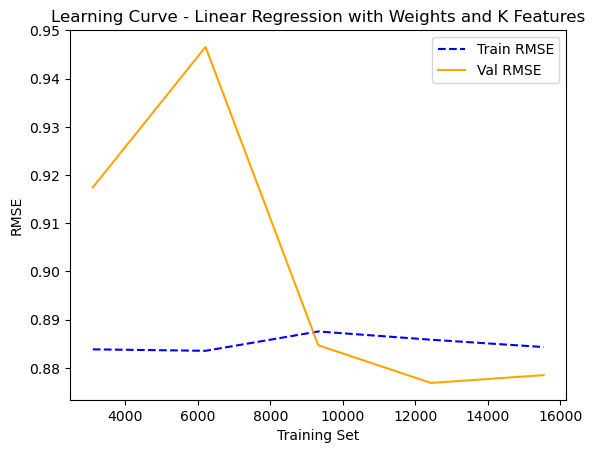

In [64]:
from sklearn.model_selection import learning_curve
sizes, train_scores, val_scores = learning_curve(
    pipeline_best,
    X_train, 
    y_train_lin,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0],
)
#===========================================================================================
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_rmse, '--', color='blue', label='Train RMSE')
plt.plot(sizes, val_rmse, color='orange', label='Val RMSE')
plt.xlabel('Training Set')
plt.ylabel('RMSE')
plt.legend()
plt.title('Learning Curve - Linear Regression with Weights and K Features')
plt.show()

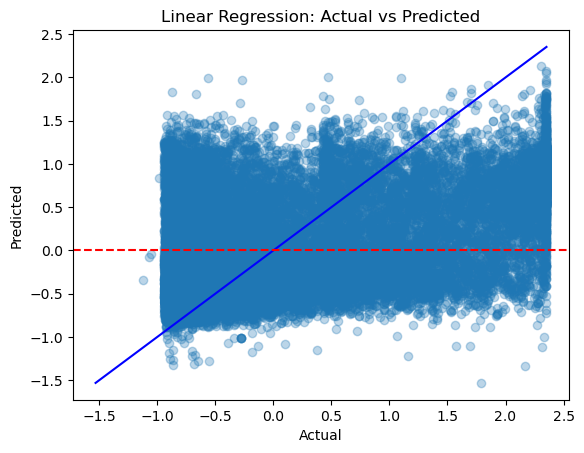

In [65]:
plt.scatter(y_val_lin, pred_val_bk, alpha=0.3)
p1 = max(max(pred_val_bk), max(y_val_lin))
p2 = min(min(pred_val_bk), min(y_val_lin))
plt.plot([p1,p2],[p1,p2],'b-')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

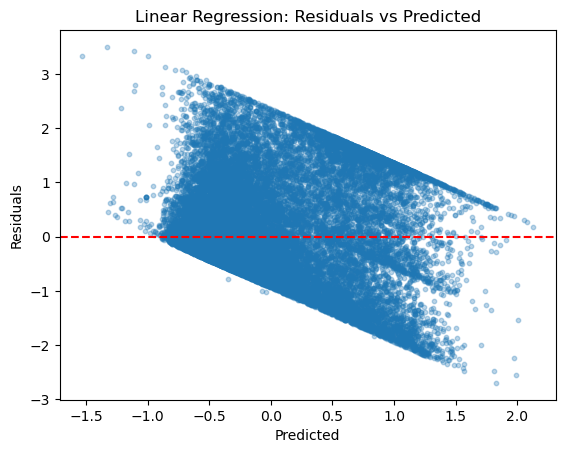

In [66]:
resid = y_val_lin - pred_val_bk
plt.scatter(pred_val_bk, resid, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residuals vs Predicted')
plt.show()

### Non-Linear Regression Models

In [67]:
# param_grid = {
#     'n_estimators': [700,800,900],
#     'max_depth': [6,7],
#     'learning_rate': [0.01,0.05],
#     'subsample': [0.7,0.9],
#     'colsample_bytree': [0.7,0.9]
# }

# xgbr = XGBRegressor(objective='reg:squarederror',random_state=42)
# grid_xgbr = GridSearchCV(xgbr, param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
# grid_xgbr.fit(X_train, y_train_lin)
# print(f"Best params: {grid_xgbr.best_params_}")
# print(f"Best CV RMSE: {-grid_xgbr.best_score_}")
#=======================================================================================================
# Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.7}
# Best CV RMSE: 0.8406326184132649

#### Non-Linear Regression Evaluated

In [68]:
xgbr = XGBRegressor(objective='reg:squarederror',
                    random_state=42,
                    colsample_bytree=0.7,
                    learning_rate=0.01,
                    max_depth=7, 
                    n_estimators=700,
                    subsample=0.7)
xgbr.fit(X_train, y_train_lin)
#===========================================================================================
pred_train_xgbr=xgbr.predict(X_train)
pred_val_xgbr=xgbr.predict(X_val)
rmse_train_xgbr = np.sqrt(mean_squared_error(y_train_lin, pred_train_xgbr))
rmse_val_xgbr = np.sqrt(mean_squared_error(y_val_lin, pred_val_xgbr))
gap_xgbr = rmse_val_xgbr - rmse_train_xgbr
r2_val_xgbr = r2_score(y_val_lin, pred_val_xgbr)
#===========================================================================================
print(f" Train RMSE: {rmse_train_by:.3f}")
print(f" Val RMSE: {rmse_val_by:.3f}")
print(f" Gap: {gap_xgbr:.3f}")
print(f" R2-Score: {r2_val_xgbr:.3f}")

 Train RMSE: 0.864
 Val RMSE: 0.889
 Gap: 0.059
 R2-Score: 0.293


In [69]:
score_xgbr = cross_val_score(xgbr, X_train, y_train_lin, cv=tscv, scoring='neg_root_mean_squared_error')
rmse_score = -score_xgbr
print("XGBoost Regression")
print(f"Mean RMSE: {rmse_score.mean():.3f}")
print(f"Std RMSE: {rmse_score.std():.3f}")
print(f"Per-fold: {rmse_score}")
print("\n")
#===========================================================================================
score_xgbr_r2 = cross_val_score(xgbr, X_train, y_train_lin, cv=tscv, scoring='r2')
r2_xgbr = score_xgbr_r2
print("XGBoost Regression")
print(f"Mean R2-Score: {r2_xgbr.mean():.3f}")
print(f"Std R2-Score: {r2_xgbr.std():.3f}")
print(f"Per-fold: {r2_xgbr}")

XGBoost Regression
Mean RMSE: 0.841
Std RMSE: 0.017
Per-fold: [0.85264343 0.8314092  0.85676905 0.85085731 0.81170714]


XGBoost Regression
Mean R2-Score: 0.287
Std R2-Score: 0.022
Per-fold: [0.25287069 0.27580731 0.28775466 0.30886764 0.31217384]


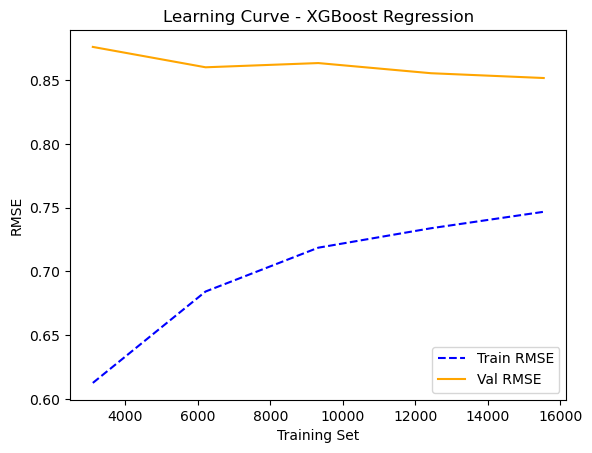

In [70]:
sizes, train_scores, val_scores = learning_curve(
    XGBRegressor(objective='reg:squarederror',
                    random_state=42,
                    colsample_bytree=0.7,
                    learning_rate=0.01,
                    max_depth=7, 
                    n_estimators=700,
                    subsample=0.7),
    X_train, 
    y_train_lin,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0],
)
#===========================================================================================
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_rmse, '--', color='blue', label='Train RMSE')
plt.plot(sizes, val_rmse, color='orange', label='Val RMSE')
plt.xlabel('Training Set')
plt.ylabel('RMSE')
plt.legend()
plt.title('Learning Curve - XGBoost Regression')
plt.show()

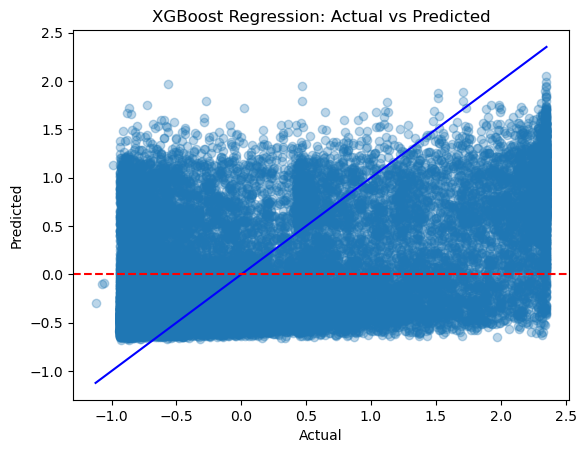

In [71]:
plt.scatter(y_val_lin, pred_val_xgbr, alpha=0.3)
p1 = max(max(pred_val_xgbr), max(y_val_lin))
p2 = min(min(pred_val_xgbr), min(y_val_lin))
plt.plot([p1,p2],[p1,p2],'b-')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost Regression: Actual vs Predicted')
plt.show()

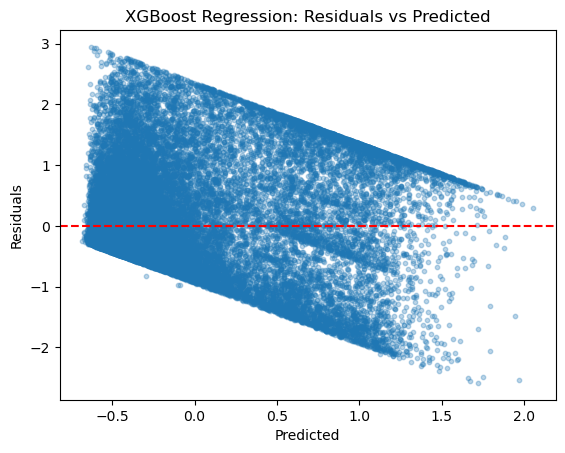

In [72]:
resid = y_val_lin - pred_val_xgbr
plt.scatter(pred_val_xgbr, resid, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('XGBoost Regression: Residuals vs Predicted')
plt.show()

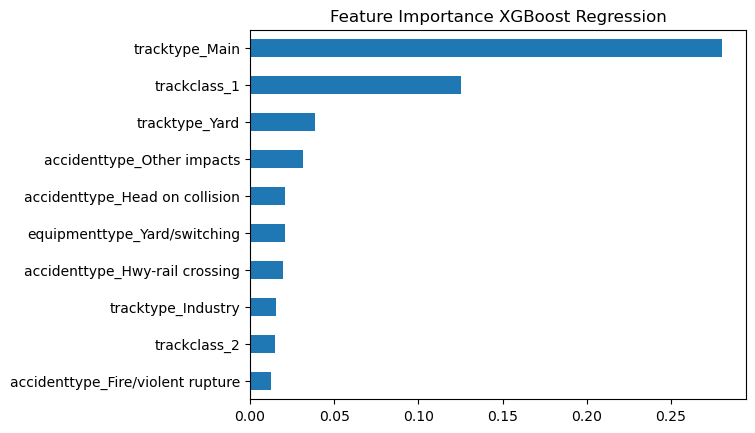

In [73]:
importance = pd.Series(xgbr.feature_importances_,index=X_train.columns).sort_values(ascending=False)
importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance XGBoost Regression')
plt.show()

### Baseline Model - KNN

In [74]:
knn_by = KNeighborsClassifier(n_neighbors=5)
knn_by.fit(X_train, y_train_knn)
pred_val_knn_by=knn_by.predict(X_val)
results_by = classification_report(y_val_knn, pred_val_knn_by)
#===========================================================================================
print("Classification Report - With Year")
print(results_by)

Classification Report - With Year
               precision    recall  f1-score   support

High Severity       0.64      0.54      0.59     16841
 Low Severity       0.57      0.67      0.62     15282

     accuracy                           0.60     32123
    macro avg       0.61      0.61      0.60     32123
 weighted avg       0.61      0.60      0.60     32123



#### KNN Tuning Best K

In [75]:
# param_grid = {
#     'select__k' : [20,50,100],
#     'knn__n_neighbors': [20,50,100],
#     'knn__weights': ['uniform','distance'],
#     'knn__p': [1,2]
# }
# #====================================================
# grid_knn = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
# grid_knn.fit(X_train, y_train_knn)
# print(f"Best params: {grid_knn.best_params_}")
# print(f"Best CV F1 (Macro): {grid_knn.best_score_:.3f}")
# #====================================================
# Best params: {'knn__n_neighbors': 100, 'knn__p': 1, 'knn__weights': 'distance', 'select__k': 100}
# Best CV F1 (Macro): 0.663

In [76]:
knn_gs = Pipeline([('select',SelectKBest(score_func=f_classif, k=100)),('knn',KNeighborsClassifier(n_neighbors = 100, p = 1, weights = 'distance'))])
knn_gs.fit(X_train, y_train_knn)
pred_val_knn_gs=knn_gs.predict(X_val)
results_gs = classification_report(y_val_knn, pred_val_knn_gs)
#===========================================================================================
print("Classification Report")
print(results_gs)

Classification Report
               precision    recall  f1-score   support

High Severity       0.73      0.49      0.58     16841
 Low Severity       0.59      0.80      0.68     15282

     accuracy                           0.64     32123
    macro avg       0.66      0.64      0.63     32123
 weighted avg       0.66      0.64      0.63     32123



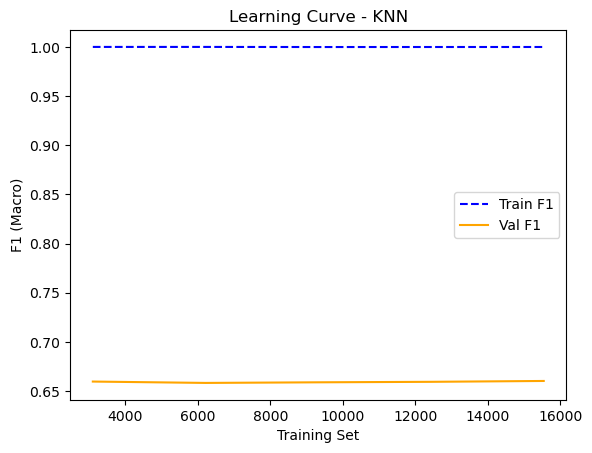

In [77]:
sizes, train_scores, val_scores = learning_curve(
    KNeighborsClassifier(n_neighbors = 100, p = 1, weights = 'distance'),
    X_train, y_train_knn, cv=tscv, scoring='f1_macro',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0])
#===========================================================================================
train_f1 = train_scores.mean(axis=1)
val_f1 = val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_f1, '--', color='blue', label='Train F1')
plt.plot(sizes, val_f1, color='orange', label='Val F1')
plt.xlabel('Training Set')
plt.ylabel('F1 (Macro)')
plt.legend()
plt.title('Learning Curve - KNN')
plt.show()

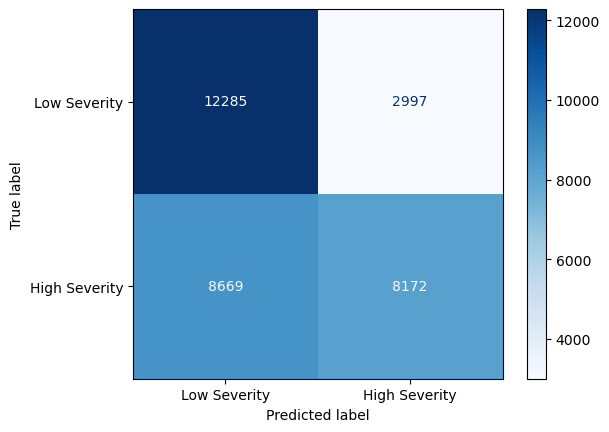

In [78]:
labels=['Low Severity', 'High Severity']
cm = confusion_matrix(y_val_knn, pred_val_knn_gs, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()

#### KNN Tuning without Best K

In [79]:
# param_grid = {
#     'n_neighbors': [20,50,100],
#     'weights': ['uniform','distance'],
#     'p': [1,2]
# }

# knn = KNeighborsClassifier()
# grid_knn = GridSearchCV(knn, param_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
# grid_knn.fit(X_train, y_train_knn)
# print(f"Best params: {grid_knn.best_params_}")
# print(f"Best CV F1 (Weighted): {grid_knn.best_score_:.3f}")
# #==========================================================
# Best params: {'n_neighbors': 100, 'p': 1, 'weights': 'uniform'}
# Best CV F1 (Weighted): 0.662

In [80]:
knn_gs2 = KNeighborsClassifier(n_neighbors = 100, p = 1, weights = 'uniform')
knn_gs2.fit(X_train, y_train_knn)
pred_val_knn_gs2=knn_gs2.predict(X_val)
results_gs2 = classification_report(y_val_knn, pred_val_knn_gs2)
#===========================================================================================
print("Classification Report")
print(results_gs2)

Classification Report
               precision    recall  f1-score   support

High Severity       0.73      0.49      0.59     16841
 Low Severity       0.59      0.80      0.68     15282

     accuracy                           0.64     32123
    macro avg       0.66      0.65      0.63     32123
 weighted avg       0.66      0.64      0.63     32123



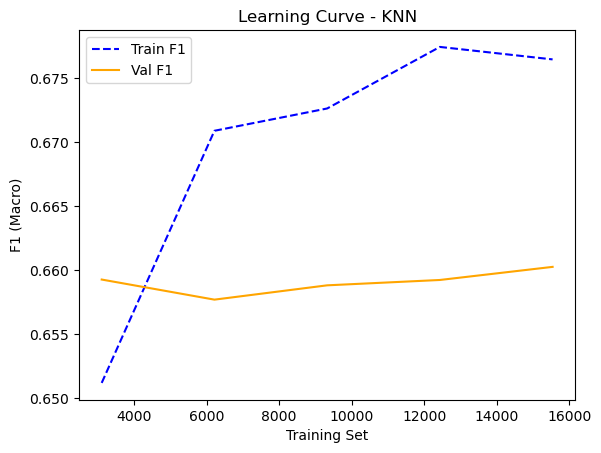

In [81]:
sizes, train_scores, val_scores = learning_curve(
    KNeighborsClassifier(n_neighbors = 100, p = 1, weights = 'uniform'),
    X_train, y_train_knn, cv=tscv, scoring='f1_macro',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0])
#===========================================================================================
train_f12 = train_scores.mean(axis=1)
val_f12 = val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_f12, '--', color='blue', label='Train F1')
plt.plot(sizes, val_f12, color='orange', label='Val F1')
plt.xlabel('Training Set')
plt.ylabel('F1 (Macro)')
plt.legend()
plt.title('Learning Curve - KNN')
plt.show()

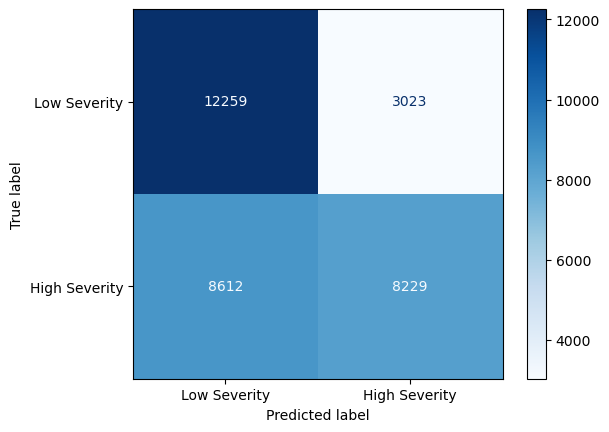

In [82]:
labels=['Low Severity', 'High Severity']
cm = confusion_matrix(y_val_knn, pred_val_knn_gs2, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()

### Non-Linear Classification Models

In [83]:
label = LabelEncoder()
y_train_label = label.fit_transform(y_train_knn)
print(label.classes_)

# param_grid = {
#     'n_estimators': [700,800,900],
#     'max_depth': [7,11,13],
#     'learning_rate': [0.01,0.05],
#     'subsample': [0.7,0.9],
#     'colsample_bytree': [0.7,0.9]
# }

# xgbc = XGBClassifier(objective='binary:logistic',random_state=42)
# grid_xgbc = GridSearchCV(xgbc, param_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
# grid_xgbc.fit(X_train, y_train_label)
# print(f"Best params: {grid_xgbc.best_params_}")
# print(f"Best CV F1 (Macro): {grid_xgbc.best_score_:.3f}")
# #==========================================================================================================
# Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.7}
# Best CV F1 (Macro): 0.675

['High Severity' 'Low Severity']


#### Non-Linear Classification Evaluated

In [84]:
xgbc = XGBClassifier(objective='binary:logistic',
                    random_state=42,
                    colsample_bytree=0.7,
                    learning_rate=0.01,
                    max_depth=7, 
                    n_estimators=700,
                    subsample=0.7)
xgbc.fit(X_train, y_train_label)
pred_val_xgbc=xgbc.predict(X_val)
#===========================================================================================
y_val_label = label.transform(y_val_knn)
#===========================================================================================
results_xgbc = classification_report(y_val_label, pred_val_xgbc)
print("Classification Report")
print(results_xgbc)

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.57      0.63     16841
           1       0.61      0.75      0.68     15282

    accuracy                           0.66     32123
   macro avg       0.66      0.66      0.65     32123
weighted avg       0.67      0.66      0.65     32123



In [85]:
score_xgbc = cross_val_score(xgbc, X_train, y_train_label, cv=tscv, scoring='f1_macro')
print("XGBoost Classification")
print(f"Mean F1 (Marco): {score_xgbc.mean():.3f}")
print(f"Std F1 (Marco): {score_xgbc.std():.3f}")
print(f"Per-fold: {score_xgbc}")

XGBoost Classification
Mean F1 (Marco): 0.675
Std F1 (Marco): 0.005
Per-fold: [0.67935825 0.67877593 0.67904118 0.67212221 0.6670244 ]


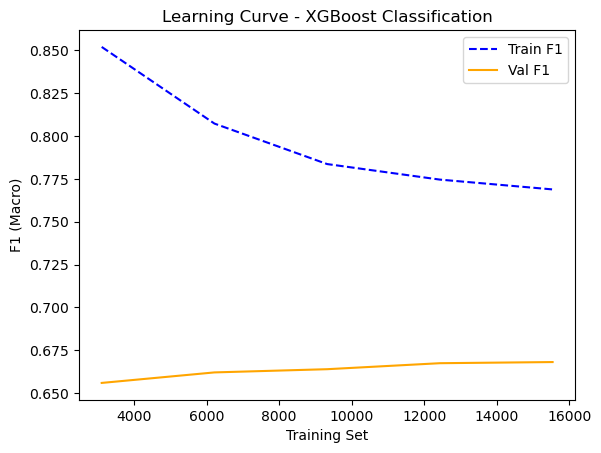

In [86]:
sizes, train_scores, val_scores = learning_curve(
        XGBClassifier(objective='binary:logistic',
                    random_state=42,
                    colsample_bytree=0.7,
                    learning_rate=0.01,
                    max_depth=7, 
                    n_estimators=700,
                    subsample=0.7),
    X_train, y_train_label, cv=tscv, scoring='f1_macro',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0])
#===========================================================================================
train_f1 = train_scores.mean(axis=1)
val_f1 = val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_f1, '--', color='blue', label='Train F1')
plt.plot(sizes, val_f1, color='orange', label='Val F1')
plt.xlabel('Training Set')
plt.ylabel('F1 (Macro)')
plt.legend()
plt.title('Learning Curve - XGBoost Classification')
plt.show()

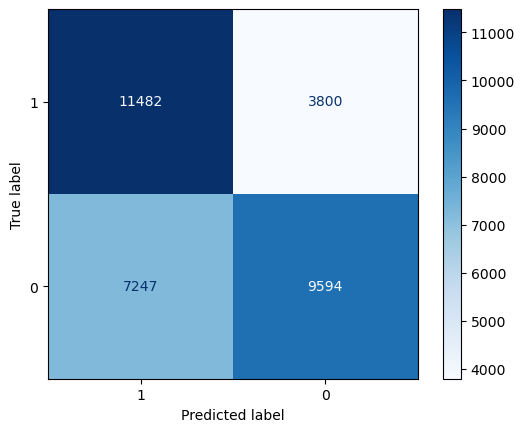

In [87]:
labels=[1,0]
cm = confusion_matrix(y_val_label, pred_val_xgbc, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()

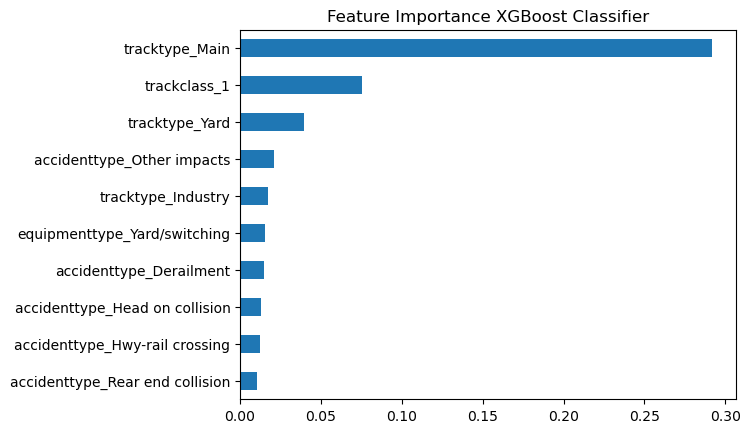

In [88]:
importance = pd.Series(xgbc.feature_importances_,index=X_train.columns).sort_values(ascending=False)
importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance XGBoost Classifier')
plt.show()

### Result Tables

In [89]:
regression_results = pd.DataFrame({'Model':['Linear Regression','+ year_weights', '+ SelectKBest (116 features)','XGBoost Regressor (Tuned)'],
                                   'Val RMSE':[0.889, 0.886, 0.886, 0.889],
                                   'R-squared':[0.252, 0.257, 0.257, 0.293]})
display(regression_results)

,Model,Val RMSE,R-squared
0,Linear Regression,0.889,0.252
1,+ year_weights,0.886,0.257
2,+ SelectKBest (116 features),0.886,0.257
3,XGBoost Regressor (Tuned),0.889,0.293


In [90]:
class_results = pd.DataFrame({'Model':['Base KNN (n_neighbors=5)','Tuned KNN', 'XGBoost Classifier (Tuned)'],
                              'Accuracy':[0.60, 0.64, 0.66],
                              'High Severity Recall':[0.54, 0.49, 0.57],
                              'High Severity F1-score':[0.59, 0.59, 0.63],
                              'Low Severity F1-score':[0.62, 0.68, 0.68]})
display(class_results)

,Model,Accuracy,High Severity Recall,High Severity F1-score,Low Severity F1-score
0,Base KNN (n_neighbors=5),0.60,0.54,0.59,0.62
1,Tuned KNN,0.64,0.49,0.59,0.68
2,XGBoost Classifier (Tuned),0.66,0.57,0.63,0.68


### Naive Model

In [91]:
mean = DummyRegressor(strategy="mean")
mean.fit(X_train, y_train_lin)
y_pred_mean = mean.predict(X_val)
dr_rmse_mean = root_mean_squared_error(y_val_lin, y_pred_mean)
print(f"Mean (Val) RMSE: {dr_rmse_mean}")

Mean (Val) RMSE: 1.0294066647189366


In [92]:
stratified = DummyClassifier(strategy="stratified", random_state=42)
stratified.fit(X_train, y_train_knn)
y_pred_stratified = stratified.predict(X_val)
f1_stratified = f1_score(y_val_knn, y_pred_stratified, average='macro')
print(f"Stratified (Val) F1 Score (Macro): {f1_stratified:.3f}")

Stratified (Val) F1 Score (Macro): 0.494


### Regression T-Test and Confidence Intervals

In [93]:
model_xgb_reg = XGBRegressor(objective='reg:squarederror',random_state=42,colsample_bytree=0.7,learning_rate=0.01,max_depth=7, n_estimators=700,subsample=0.7)
model_dummy_reg = DummyRegressor(strategy="mean")
#===========================================================================================
scores_xgb_rmse = cross_val_score(model_xgb_reg, X_train, y_train_lin, cv=tscv, scoring='neg_root_mean_squared_error')
scores_dummy_rmse = cross_val_score(model_dummy_reg, X_train, y_train_lin, cv=tscv, scoring='neg_root_mean_squared_error')
#===========================================================================================
scores_xgb_rmse = -scores_xgb_rmse
scores_dummy_rmse = -scores_dummy_rmse
#===========================================================================================
scores_xgb_r2 = cross_val_score(model_xgb_reg, X_train, y_train_lin, cv=tscv, scoring='r2')
scores_dummy_r2 = cross_val_score(model_dummy_reg, X_train, y_train_lin, cv=tscv, scoring='r2')
#===========================================================================================
print("RMSE Scores")
print(f"XGBoost Regression - Mean RMSE: {scores_xgb_rmse.mean():.3f} (+/- {scores_xgb_rmse.std():.3f})")
print(f"Dummy Baseline - Mean RMSE: {scores_dummy_rmse.mean():.3f} (+/- {scores_dummy_rmse.std():.3f})")
print(f"\nR-squared Scores")
print(f"XGBoost Regression - Mean R2: {scores_xgb_r2.mean():.3f} (+/- {scores_xgb_r2.std():.3f})")
print(f"Dummy Baseline - Mean R2: {scores_dummy_r2.mean():.3f} (+/- {scores_dummy_r2.std():.3f})")

RMSE Scores
XGBoost Regression - Mean RMSE: 0.841 (+/- 0.017)
Dummy Baseline - Mean RMSE: 0.997 (+/- 0.020)

R-squared Scores
XGBoost Regression - Mean R2: 0.287 (+/- 0.022)
Dummy Baseline - Mean R2: -0.002 (+/- 0.001)


In [94]:
t_stat_r2, p_value_r2 = ttest_rel(scores_xgb_r2, scores_dummy_r2)
print("Paired t-test (R-squared)")
print(f"t-statistic: {t_stat_r2:.3f}")
print(f"p-value: {p_value_r2:.7f}")
print(f"Mean R2 difference: {(scores_xgb_r2 - scores_dummy_r2).mean():.3f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_r2 < 0.05:
    print("REJECT H0 - Significant difference in R-squared.")
else:
    print("FAIL TO REJECT H0 - No significant difference.")
#===========================================================================================
#===========================================================================================
t_stat_rmse, p_value_rmse = ttest_rel(scores_xgb_rmse, scores_dummy_rmse)
print("Paired t-test (RMSE)")
print(f"t-statistic: {t_stat_rmse:.3f}")
print(f"p-value: {p_value_rmse:.7f}")
print(f"Mean RMSE difference: {(scores_xgb_rmse - scores_dummy_rmse).mean():.3f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_rmse < 0.05:
    print("REJECT H0 - Significant difference in RMSE.")
else:
    print("FAIL TO REJECT H0 - No significant difference.")

Paired t-test (R-squared)
t-statistic: 26.256
p-value: 0.0000125
Mean R2 difference: 0.290

Conclusion at alpha=0.05: REJECT H0 - Significant difference in R-squared.
Paired t-test (RMSE)
t-statistic: -21.835
p-value: 0.0000260
Mean RMSE difference: -0.157

Conclusion at alpha=0.05: REJECT H0 - Significant difference in RMSE.


In [95]:
bootstrap = 10000
np.random.seed(42)
#===========================================================================================
diff_r2 = scores_xgb_r2 - scores_dummy_r2
bootstrap_r2 = []
for _ in range(bootstrap):
    sample = np.random.choice(diff_r2, size=len(diff_r2), replace=True)
    bootstrap_r2.append(sample.mean())
bootstrap_r2 = np.array(bootstrap_r2)
#===========================================================================================
print("Bootstrap 95% CI for R-squared Difference")
ci_r2_lower, ci_r2_upper = np.percentile(bootstrap_r2, [2.5, 97.5])
print(f"Mean R2 Diff: {diff_r2.mean():.3f}")
print(f"95% CI: {ci_r2_lower:.3f}, {ci_r2_upper:.3f}")
print(f"Contain 0: {'Yes' if ci_r2_lower <= 0 <= ci_r2_upper else 'No'}")
print("\n")
#===========================================================================================
#===========================================================================================
diff_rmse = scores_xgb_rmse - scores_dummy_rmse
bootstrap_rmse = []
for _ in range(bootstrap):
    sample = np.random.choice(diff_rmse, size=len(diff_rmse), replace=True)
    bootstrap_rmse.append(sample.mean())
bootstrap_rmse = np.array(bootstrap_rmse)
#===========================================================================================
print("Bootstrap 95% CI for RMSE Difference")
ci_rmse_lower, ci_rmse_upper = np.percentile(bootstrap_rmse, [2.5, 97.5])
print(f"Mean RMSE Diff: {diff_rmse.mean():.3f}")
print(f"95% CI: {ci_rmse_lower:.3f}, {ci_rmse_upper:.3f}")
print(f"Contain 0: {'Yes' if ci_rmse_lower <= 0 <= ci_rmse_upper else 'No'}")

Bootstrap 95% CI for R-squared Difference
Mean R2 Diff: 0.290
95% CI: 0.270, 0.308
Contain 0: No


Bootstrap 95% CI for RMSE Difference
Mean RMSE Diff: -0.157
95% CI: -0.169, -0.144
Contain 0: No


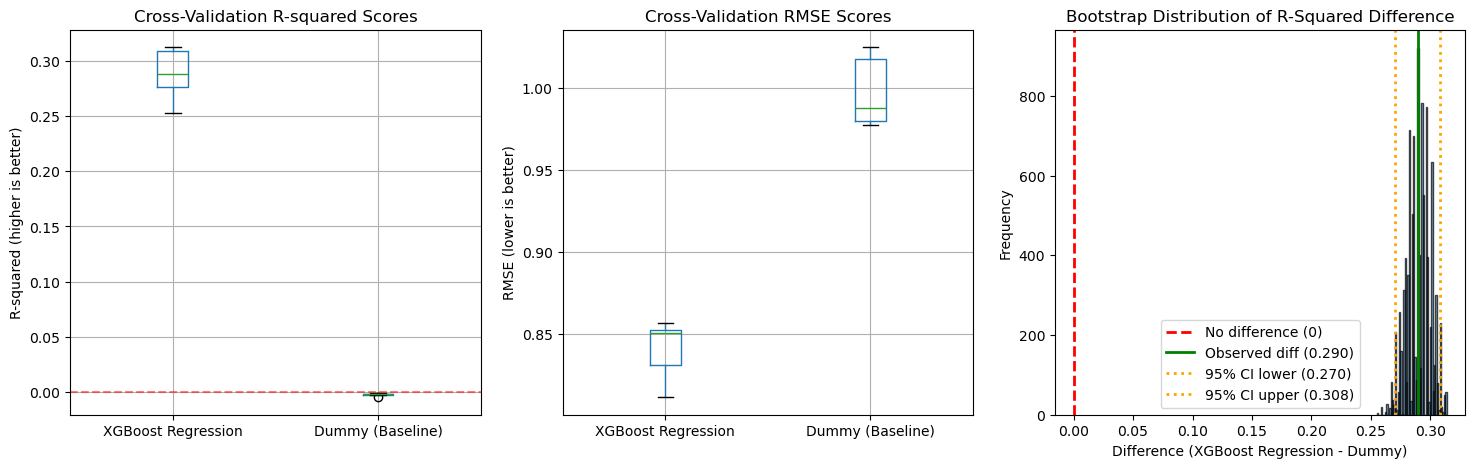

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#===========================================================================================
r2_df = pd.DataFrame({
    'XGBoost Regression': scores_xgb_r2,
    'Dummy (Baseline)': scores_dummy_r2
})
r2_df.boxplot(ax=axes[0])
axes[0].set_title('Cross-Validation R-squared Scores')
axes[0].set_ylabel('R-squared (higher is better)')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
#===========================================================================================
#===========================================================================================
rmse_df = pd.DataFrame({
    'XGBoost Regression': scores_xgb_rmse,
    'Dummy (Baseline)': scores_dummy_rmse
})
rmse_df.boxplot(ax=axes[1])
axes[1].set_title('Cross-Validation RMSE Scores')
axes[1].set_ylabel('RMSE (lower is better)')
#===========================================================================================
axes[2].hist(bootstrap_r2, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference (0)')
axes[2].axvline(x=diff_r2.mean(), color='green', linestyle='-', linewidth=2, label=f'Observed diff ({diff_r2.mean():.3f})')
axes[2].axvline(x=ci_r2_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI lower ({ci_r2_lower:.3f})')
axes[2].axvline(x=ci_r2_upper, color='orange', linestyle=':', linewidth=2, label=f'95% CI upper ({ci_r2_upper:.3f})')
axes[2].set_title('Bootstrap Distribution of R-Squared Difference')
axes[2].set_xlabel('Difference (XGBoost Regression - Dummy)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
#===========================================================================================
plt.tight_layout
plt.show()

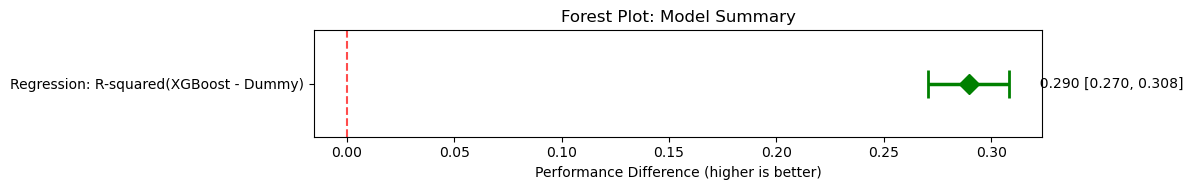

In [97]:
fig, ax = plt.subplots(figsize=(12,2))
comparisons =[{'label':'Regression: R-squared(XGBoost - Dummy)',
              'mean':diff_r2.mean(),
              'lower':ci_r2_lower,
              'upper':ci_r2_upper}]
#===========================================================================================
for i, comp in enumerate(comparisons):
    color = 'green' if comp['lower'] > 0 else ('red' if comp['upper'] < 0 else 'gray')
    ax.errorbar(comp['mean'], i,
                xerr=[[comp['mean'] - comp['lower']], [comp['upper'] - comp['mean']]],
                fmt='D', color=color, ecolor=color, capsize=10, capthick=2,
                markersize=10, elinewidth=2.5)
    ax.text(comp['upper'] + 0.01, i,
            f"  {comp['mean']:.3f} [{comp['lower']:.3f}, {comp['upper']:.3f}]",
            va='center', fontsize=10)
#===========================================================================================
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(range(len(comparisons)))
ax.set_yticklabels([c['label'] for c in comparisons])
ax.set_xlabel('Performance Difference (higher is better)')
ax.set_title('Forest Plot: Model Summary')
plt.tight_layout()
plt.show()

### Classification T-Test and Confidence Intervals

In [98]:
model_xgb_cl = XGBClassifier(objective='binary:logistic',random_state=42,colsample_bytree=0.7,learning_rate=0.01,max_depth=7, n_estimators=700,subsample=0.7)
model_dummy_cl = DummyClassifier(strategy="stratified", random_state=42)
#===========================================================================================
scores_xgb_f1m = cross_val_score(model_xgb_cl, X_train, y_train_label, cv=tscv, scoring='f1_macro')
scores_dummy_f1m = cross_val_score(model_dummy_cl, X_train, y_train_label, cv=tscv, scoring='f1_macro')
#===========================================================================================
print("F1 Macro Scores")
print(f"XGBoost Classification - Mean F1 Macro: {scores_xgb_f1m.mean():.3f} (+/- {scores_xgb_f1m.std():.3f})")
print(f"Dummy Baseline - Mean F1 Macro: {scores_dummy_f1m.mean():.3f} (+/- {scores_dummy_f1m.std():.3f})")
print(f"Number of paired scores: {len(scores_xgb_f1m)}")
print(f"Observed Mean Diff: {scores_xgb_f1m.mean() - scores_dummy_f1m.mean():.3f}")

F1 Macro Scores
XGBoost Classification - Mean F1 Macro: 0.675 (+/- 0.005)
Dummy Baseline - Mean F1 Macro: 0.503 (+/- 0.002)
Number of paired scores: 5
Observed Mean Diff: 0.173


In [99]:
t_stat_f1m, p_value_f1m = ttest_rel(scores_xgb_f1m, scores_dummy_f1m)
print("Paired t-test (F1 Macro)")
print(f"t-statistic: {t_stat_f1m:.3f}")
print(f"p-value: {p_value_f1m:.7f}")
print(f"Mean F1 Macro difference: {(scores_xgb_f1m - scores_dummy_f1m).mean():.3f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_f1m < 0.05:
    print("REJECT H0 - Significant difference in F1 Macro.")
else:
    print("FAIL TO REJECT H0 - No significant difference.")

Paired t-test (F1 Macro)
t-statistic: 54.847
p-value: 0.0000007
Mean F1 Macro difference: 0.173

Conclusion at alpha=0.05: REJECT H0 - Significant difference in F1 Macro.


In [100]:
bootstrap = 10000
np.random.seed(42)
#======================================================================================
diff_f1m = scores_xgb_f1m - scores_dummy_f1m
observed_diff_f1m = diff_f1m.mean()
#======================================================================================
bootstrap_f1m = []
for _ in range(bootstrap):
    sample = np.random.choice(diff_f1m, size=len(diff_f1m), replace=True)
    bootstrap_f1m.append(sample.mean())
bootstrap_f1m = np.array(bootstrap_f1m)
#======================================================================================
print("Bootstrap 95% CI for F1 Macro Difference")
ci_f1m_lower, ci_f1m_upper = np.percentile(bootstrap_f1m, [2.5, 97.5])
print(f"Mean F1 Macro Diff: {observed_diff_f1m.mean():.3f}")
print(f"95% CI: {ci_f1m_lower:.3f}, {ci_f1m_upper:.3f}")
print(f"Contain 0: {'Yes' if ci_f1m_lower <= 0 <= ci_f1m_upper else 'No'}")

Bootstrap 95% CI for F1 Macro Difference
Mean F1 Macro Diff: 0.173
95% CI: 0.167, 0.178
Contain 0: No


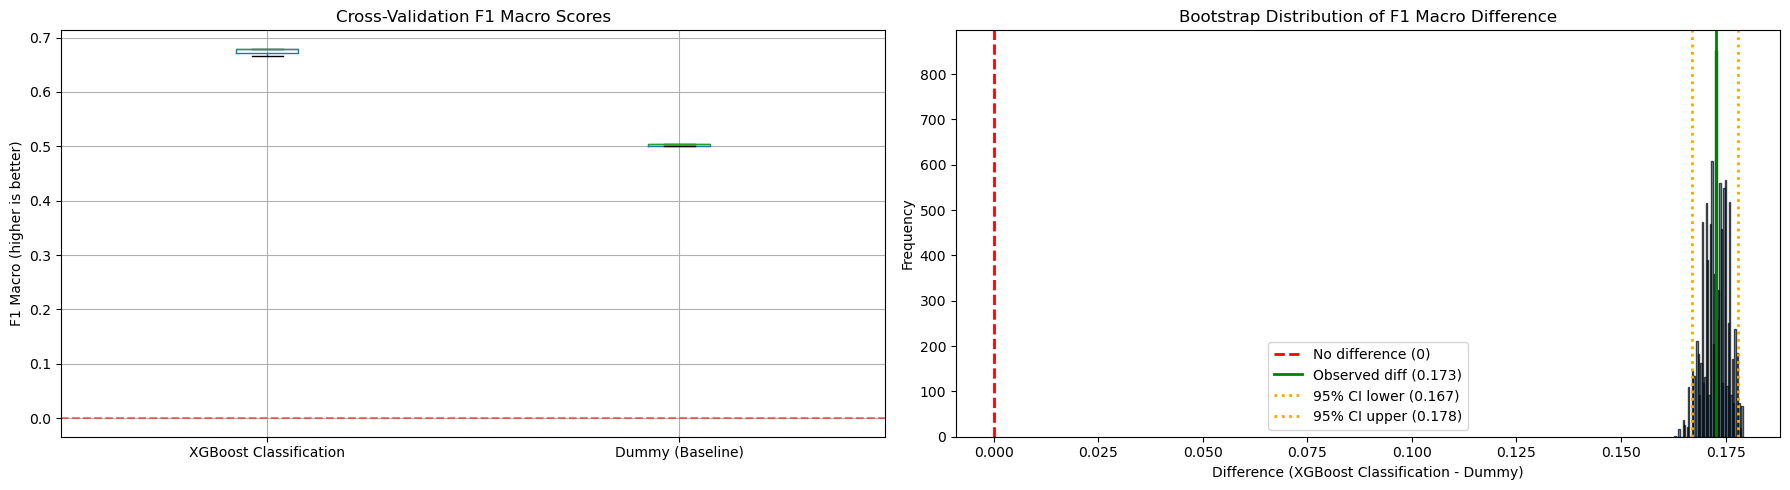

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
#=======================================================================================
f1m_df = pd.DataFrame({
    'XGBoost Classification': scores_xgb_f1m,
    'Dummy (Baseline)': scores_dummy_f1m})
f1m_df.boxplot(ax=axes[0])
axes[0].set_title('Cross-Validation F1 Macro Scores')
axes[0].set_ylabel('F1 Macro (higher is better)')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
#=======================================================================================
axes[1].hist(bootstrap_f1m, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference (0)')
axes[1].axvline(x=observed_diff_f1m, color='green', linestyle='-', linewidth=2, label=f'Observed diff ({observed_diff_f1m:.3f})')
axes[1].axvline(x=ci_f1m_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI lower ({ci_f1m_lower:.3f})')
axes[1].axvline(x=ci_f1m_upper, color='orange', linestyle=':', linewidth=2, label=f'95% CI upper ({ci_f1m_upper:.3f})')
axes[1].set_title('Bootstrap Distribution of F1 Macro Difference')
axes[1].set_xlabel('Difference (XGBoost Classification - Dummy)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
#=======================================================================================
plt.tight_layout()
plt.show()

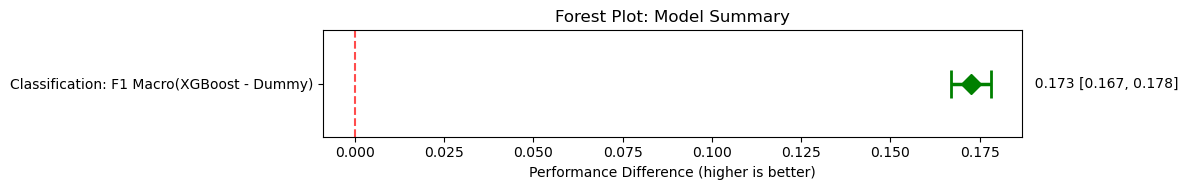

In [102]:
fig, axes = plt.subplots(figsize=(12,2))
comparisons =[{'label':'Classification: F1 Macro(XGBoost - Dummy)',
              'mean':diff_f1m.mean(),
              'lower':ci_f1m_lower,
              'upper':ci_f1m_upper}]
#===========================================================================================
for i, comp in enumerate(comparisons):
    color = 'green' if comp['lower'] > 0 else ('red' if comp['upper'] < 0 else 'gray')
    axes.errorbar(comp['mean'], i,
                xerr=[[comp['mean'] - comp['lower']], [comp['upper'] - comp['mean']]],
                fmt='D', color=color, ecolor=color, capsize=10, capthick=2,
                markersize=10, elinewidth=2.5)
    axes.text(comp['upper'] + 0.01, i,
            f"  {comp['mean']:.3f} [{comp['lower']:.3f}, {comp['upper']:.3f}]",
            va='center', fontsize=10)
#===========================================================================================
axes.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes.set_yticks(range(len(comparisons)))
axes.set_yticklabels([c['label'] for c in comparisons])
axes.set_xlabel('Performance Difference (higher is better)')
axes.set_title('Forest Plot: Model Summary')
plt.tight_layout()
plt.show()

### Final Model Results

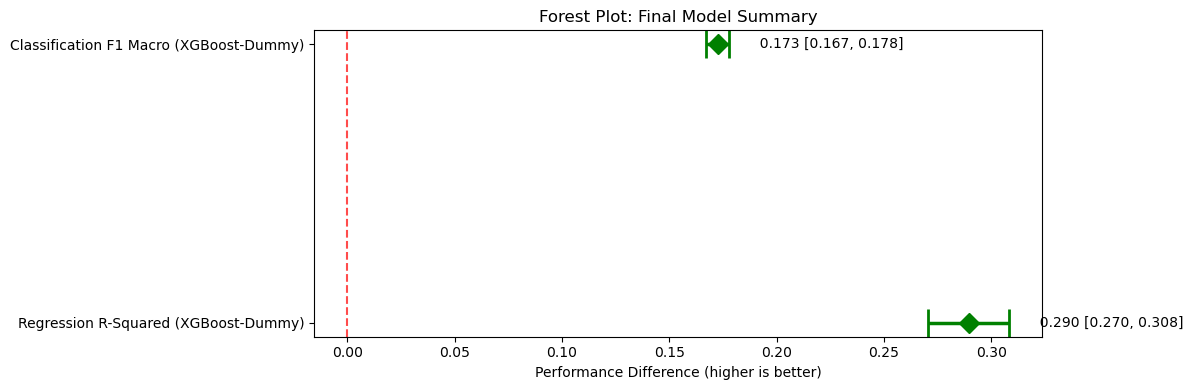

In [103]:
fig, axes = plt.subplots(figsize=(12,4))
comparisons = [
    {"label": "Regression R-Squared (XGBoost-Dummy)",
     "mean": diff_r2.mean(),
     "lower": ci_r2_lower,
     "upper": ci_r2_upper},
    {"label": "Classification F1 Macro (XGBoost-Dummy)",
     "mean": diff_f1m.mean(),
     "lower": ci_f1m_lower,
     "upper": ci_f1m_upper}]
#===========================================================================================
for i, comp in enumerate(comparisons):
    color = 'green' if comp['lower'] > 0 else ('red' if comp['upper'] < 0 else 'gray')
    axes.errorbar(comp['mean'], i,
                xerr=[[comp['mean'] - comp['lower']], [comp['upper'] - comp['mean']]],
                fmt='D', color=color, ecolor=color, capsize=10, capthick=2,
                markersize=10, elinewidth=2.5)
    axes.text(comp['upper'] + 0.01, i,
            f"  {comp['mean']:.3f} [{comp['lower']:.3f}, {comp['upper']:.3f}]",
            va='center', fontsize=10)
#===========================================================================================
axes.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes.set_yticks(range(len(comparisons)))
axes.set_yticklabels([c['label'] for c in comparisons])
axes.set_xlabel('Performance Difference (higher is better)')
axes.set_title('Forest Plot: Final Model Summary')
plt.tight_layout()
plt.show()

In [104]:
results_summary = pd.DataFrame({
    'Comparison': ['Classification (F1 Macro)', 'Regression (R-squared)', 'Regression (RMSE)'],
    'Model Mean': [
        f"{scores_xgb_f1m.mean():.3f}",
        f"{scores_xgb_r2.mean():.3f}",
        f"{scores_xgb_rmse.mean():.3f}"],
    'Baseline Mean': [
        f"{scores_dummy_f1m.mean():.3f}",
        f"{scores_dummy_r2.mean():.3f}",
        f"{scores_dummy_rmse.mean():.3f}"],
    'Mean Diff': [
        f"{diff_f1m.mean():.3f}",
        f"{diff_r2.mean():.3f}",
        f"{diff_rmse.mean():.3f}"],
    '95% CI': [
        f"[{ci_f1m_lower:.3f}, {ci_f1m_upper:.3f}]",
        f"[{ci_r2_lower:.3f}, {ci_r2_upper:.3f}]",
        f"[{ci_rmse_lower:.3f}, {ci_rmse_upper:.3f}]"],
    'p-value (t-test)': [
        f"{p_value_f1m:.6f}",
        f"{p_value_r2:.6f}",
        f"{p_value_rmse:.6f}"],
    'Significant?': [
        'Yes' if p_value_f1m < 0.05 else 'No',
        'Yes' if p_value_r2 < 0.05 else 'No',
        'Yes' if p_value_rmse < 0.05 else 'No']})
#===========================================================================================
print("Summary of All Model Comparisons")
display(results_summary)

Summary of All Model Comparisons


,Comparison,Model Mean,Baseline Mean,Mean Diff,95% CI,p-value (t-test),Significant?
0,Classification (F1 Macro),0.675,0.503,0.173,"[0.167, 0.178]",0.000001,Yes
1,Regression (R-squared),0.287,-0.002,0.290,"[0.270, 0.308]",0.000013,Yes
2,Regression (RMSE),0.841,0.997,-0.157,"[-0.169, -0.144]",0.000026,Yes


### Test Set Final Results

#### Regression Test

In [105]:
pred_test_xgbr = xgbr.predict(X_test)
rmse_test_xgbr = np.sqrt(mean_squared_error(y_test_lin, pred_test_xgbr))
r2_test_xgbr = r2_score(y_val_lin, pred_val_xgbr)
#===========================================================================================
print(f" Test RMSE: {rmse_test_xgbr:.3f}")
print(f" R2-Score: {r2_test_xgbr:.3f}")

 Test RMSE: 0.934
 R2-Score: 0.293


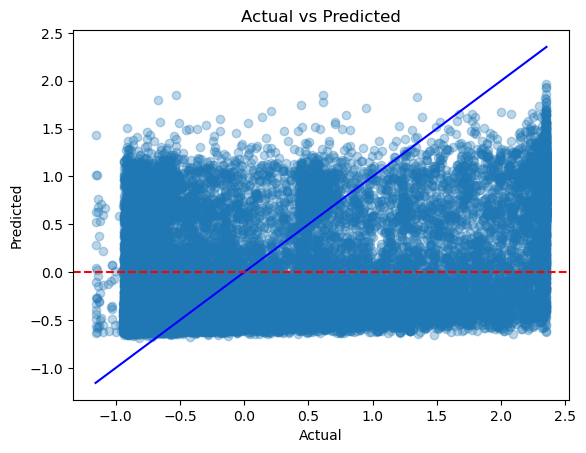

In [106]:
plt.scatter(y_test_lin, pred_test_xgbr, alpha=0.3)
p1 = max(max(pred_test_xgbr), max(y_test_lin))
p2 = min(min(pred_test_xgbr), min(y_test_lin))
plt.plot([p1,p2],[p1,p2],'b-')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

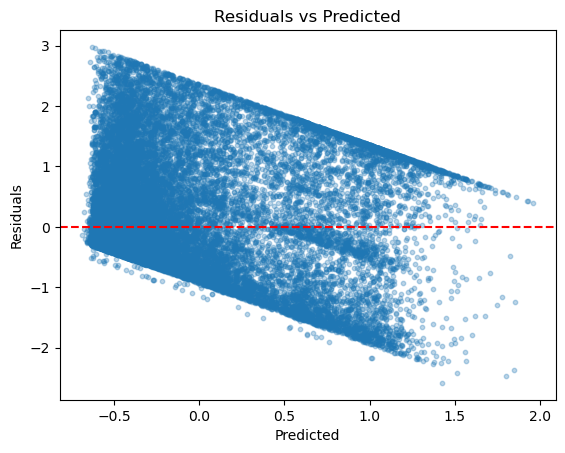

In [107]:
resid = y_test_lin - pred_test_xgbr
plt.scatter(pred_test_xgbr, resid, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

#### Classification Test

In [108]:
y_test_label = label.transform(y_test_knn)
pred_test_xgbc = xgbc.predict(X_test)
#===========================================================================================
results_xgbc = classification_report(y_test_label, pred_test_xgbc)
print("Classification Report")
print(results_xgbc)

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.50      0.58     15449
           1       0.56      0.73      0.63     13200

    accuracy                           0.61     28649
   macro avg       0.62      0.62      0.61     28649
weighted avg       0.63      0.61      0.60     28649



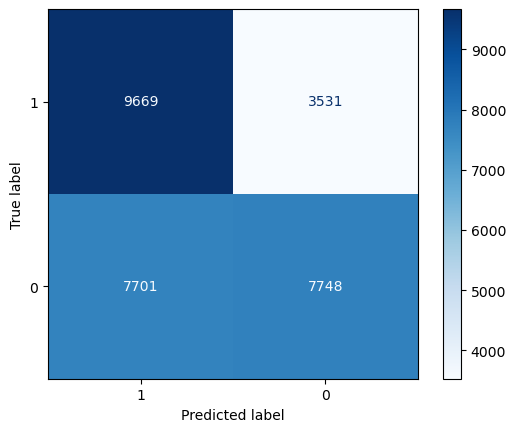

In [109]:
labels=[1,0]
cm = confusion_matrix(y_test_label, pred_test_xgbc, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()